In [1]:
#!/usr/bin/env python
# coding: utf-8

# # Cairo Hotels - Exploratory Data Analysis (EDA)
# ## TourMate AI - Data Intelligence Report
#
# **Date:** June 2026
# **Analyst:** TourMate AI Data Science Team
# **Dataset:** `data/cairo_places_filled (9).json` - 6,600+ places across Cairo, Egypt
#
# This notebook performs a **deep-dive EDA** focused exclusively on **Hotels** in Cairo.
#
# ---

# ## 0. Environment Setup & Imports


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from collections import Counter

# Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Folium
import folium
from folium.plugins import HeatMap, MarkerCluster

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from utils import (
    extract_location, detect_outliers_iqr, derive_features,
    get_hashable_cols, compute_popularity, compute_recommendation_scores,
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (14, 7)

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

print('[OK] All libraries loaded successfully.')

# ---
# ## 1. Data Loading & Initial Inspection


[OK] All libraries loaded successfully.


In [3]:
DATA_PATH = '../data/cairo_places_filled (11).json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print(f'Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# ---
# ## 2. Filter to Hotels


Dataset Shape: 6,556 rows x 28 columns
Columns: ['id', 'name', 'category', 'category_label', 'description', 'rating', 'review_count', 'city', 'country', 'lat', 'lon', 'address', 'phone', 'website', 'maps_link', 'photos', 'reviews', 'hours', 'subtype', 'cuisine_type', 'price_level', 'avg_cost_per_person', 'reservation_link', 'star_class', 'nightly_rate', 'booking_platforms', 'amenities', 'neighborhood']
Memory Usage: 14.9 MB


In [4]:
df_hotel = df[df['category'] == 'hotel'].copy().reset_index(drop=True)

print(f'Filtered to Hotels: {len(df_hotel):,} places out of {len(df):,} total')
print(f'\nFull dataset category breakdown:')
print(df['category'].value_counts().to_string())


Filtered to Hotels: 771 places out of 6,556 total

Full dataset category breakdown:
category
restaurant     4276
attractions    1509
hotel           771


In [5]:
df_hotel.head()


,id,name,category,category_label,description,rating,review_count,city,country,lat,lon,address,phone,website,maps_link,photos,reviews,hours,subtype,cuisine_type,price_level,avg_cost_per_person,reservation_link,star_class,nightly_rate,booking_platforms,amenities,neighborhood
0,lo-0F7814A8,InterContinental Cairo Semiramis by IHG,hotel,Hotel / Lodging,"InterContinental Cairo Semiramis, located on t...",4.800,57217,Cairo,Egypt,30.043,31.232,"Nile Corniche, Qasr Ad Dobarah, Qasr El Nil, C...",02 27988000,https://www.ihg.com/intercontinental/hotels/gb...,https://www.google.com/maps/place/InterContine...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,[had a wonderful experience at the restaurant ...,NaN,Hotel,NaN,NaN,NaN,NaN,5.000,$152.66,"[Trip.com, Priceline]","[Pool, Spa, Gym, Free WiFi, Free Breakfast, Fr...",Garden City
1,lo-295663F9,Sofitel Cairo Nile El Gezirah,hotel,Hotel / Lodging,"Sofitel Cairo Nile El Gezirah, located at the ...",4.800,39192,Cairo,Egypt,30.039,31.225,"3 El Thawra Council St Zamalek, El Orman, Cair...",02 27373737,http://sofitel.accor.com/hotels/5307?merchanti...,https://www.google.com/maps/place/Sofitel+Cair...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,"[Very nice hotel, quietly located right in the...",NaN,Hotel,NaN,NaN,NaN,NaN,5.000,$170.81,"[Trip.com, Priceline]","[Pool, Spa, Gym, Free WiFi, Free Breakfast, Fr...",Zamalek
2,lo-66862FFE,InterContinental Citystars Cairo by IHG,hotel,Hotel / Lodging,"InterContinental Citystars Cairo by IHG, locat...",4.700,36682,Cairo,Egypt,30.073,31.348,"Omar Ibn El-Khattab, Street, Nasr City, Cairo ...",02 24800100,https://www.ihg.com/intercontinental/hotels/gb...,https://www.google.com/maps/place/InterContine...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,[I had a wonderful stay at this hotel. The atm...,NaN,Hotel,NaN,NaN,NaN,NaN,5.000,$259.51,"[Agoda, Trip.com]","[Pool, Spa, Gym, Free WiFi, Free Breakfast, Fr...",East Nasr City
3,lo-BB9812AD,Novotel Cairo Airport,hotel,Hotel / Lodging,"Novotel Cairo Airport, located in the El Nozha...",4.600,29887,Cairo,Egypt,30.123,31.402,"Cairo Airport, Sheraton Al Matar, El Nozha, Ca...",011 11113822,https://all.accor.com/lien_externe.svlt?goto=f...,https://www.google.com/maps/place/Novotel+Cair...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,"[Overall, this is a nice hotel and very close ...",NaN,Hotel,NaN,NaN,NaN,NaN,4.000,$58.83,[Trip.com],"[Pool, Gym, Free WiFi, Free Breakfast, Free Pa...",El Nozha
4,lo-C19422F8,Ramses Hilton,hotel,Hotel / Lodging,"Ramses Hilton, located on the Nile Corniche ju...",4.200,29736,Cairo,Egypt,30.050,31.232,"1115 Nile Corniche, Sharkas, Bulaq, Cairo Gove...",02 25777444,https://www.hilton.com/en/hotels/cairhtw-ramse...,https://www.google.com/maps/place/Ramses+Hilto...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,[I would like to recognise the following names...,NaN,Hotel,NaN,NaN,NaN,NaN,5.000,$89.11,"[Trip.com, Priceline]","[Pool, Gym, Free WiFi, Free Breakfast, Free Pa...",Bulaq


In [6]:
df_hotel.info()


<class 'pandas.DataFrame'>
RangeIndex: 771 entries, 0 to 770
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   771 non-null    str    
 1   name                 771 non-null    str    
 2   category             771 non-null    str    
 3   category_label       771 non-null    str    
 4   description          771 non-null    str    
 5   rating               771 non-null    float64
 6   review_count         771 non-null    int64  
 7   city                 771 non-null    str    
 8   country              771 non-null    str    
 9   lat                  771 non-null    float64
 10  lon                  771 non-null    float64
 11  address              771 non-null    str    
 12  phone                688 non-null    str    
 13  website              419 non-null    str    
 14  maps_link            771 non-null    str    
 15  photos               771 non-null    object 
 16  r

In [7]:
hashable_cols = get_hashable_cols(df_hotel)

print(f'Hashable columns: {len(hashable_cols)} of {len(df_hotel.columns)}')


Hashable columns: 23 of 28


In [8]:
df_hotel[hashable_cols].describe(include='all')

# ---
# ## 3. Derive Features


,id,name,category,category_label,description,rating,review_count,city,country,lat,lon,address,phone,website,maps_link,subtype,cuisine_type,price_level,avg_cost_per_person,reservation_link,star_class,nightly_rate,neighborhood
count,771,771,771,771,771,771.000,771.000,771,771,771.000,771.000,771,688,419,771,771,0,0,0,0.000,311.000,728,728
unique,771,766,1,1,771,NaN,NaN,1,1,NaN,NaN,754,662,407,771,4,0,0,0,NaN,NaN,637,55
top,lo-0F7814A8,Swiss Inn Nile Hotel,hotel,Hotel / Lodging,"InterContinental Cairo Semiramis, located on t...",NaN,NaN,Cairo,Egypt,NaN,NaN,"16 Adel Hussein Rostom, Ad Doqi A, Dokki, Giza...",010 33002049,http://www.stayatprime.com/,https://www.google.com/maps/place/InterContine...,Hotel,NaN,NaN,NaN,NaN,NaN,$67.32,Al Omraneya
freq,1,2,771,771,1,NaN,NaN,771,771,NaN,NaN,2,3,4,1,754,NaN,NaN,NaN,NaN,NaN,6,217
mean,NaN,NaN,NaN,NaN,NaN,4.220,1262.923,NaN,NaN,30.027,31.236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.424,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.516,4493.217,NaN,NaN,0.064,0.197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.113,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.600,5.000,NaN,NaN,29.901,27.206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,3.900,36.000,NaN,NaN,29.982,31.144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,4.300,112.000,NaN,NaN,30.038,31.236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,4.600,372.500,NaN,NaN,30.052,31.299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000,NaN,NaN


In [9]:
df_hotel = derive_features(df_hotel)

print('Derived features created: photo_count, review_text_count, avg_review_length, has_hours, district, area')

# ---
# ## 4. Data Quality Assessment


Derived features created: photo_count, review_text_count, avg_review_length, has_hours, district, area


  DATA QUALITY: HOTEL (771 places)

Columns with Missing Values (hotel):
             column  missing_count  missing_pct
        price_level            771      100.000
avg_cost_per_person            771      100.000
   reservation_link            771      100.000
       cuisine_type            771      100.000
         star_class            460       59.660
            website            352       45.650
              phone             83       10.770
       neighborhood             43        5.580
       nightly_rate             43        5.580


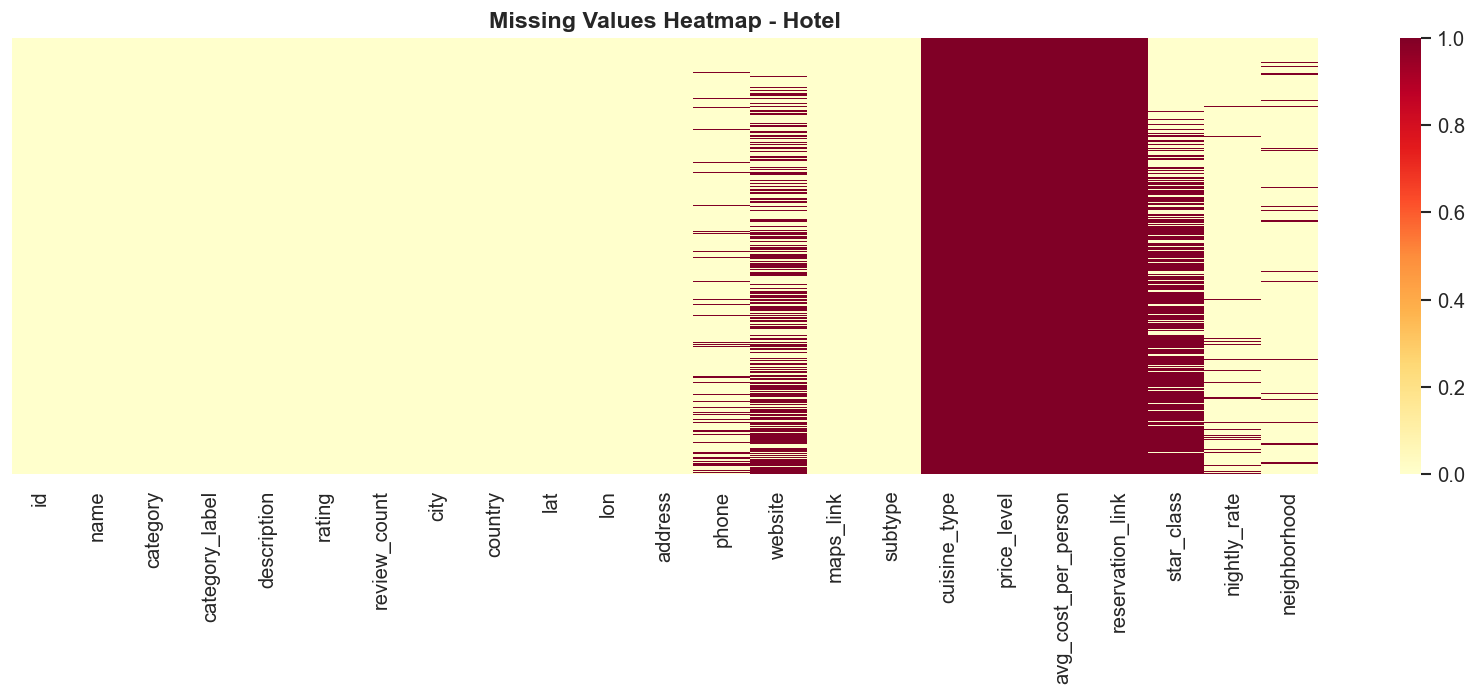


Exact duplicate rows: 0
Duplicate id values: 0
[WARN] 1 rows with coordinates outside Cairo area

DATA QUALITY REPORT - HOTEL
                             Value
Total Records              771.000
Total Columns               34.000
Exact Duplicates             0.000
Columns with Missing Data    9.000
Total Missing Cells       4065.000
Memory Usage (MB)            1.700


In [10]:
print('=' * 70)
print(f'  DATA QUALITY: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

cat_hashable = [c for c in hashable_cols if c in df_hotel.columns]

# Missing values
missing = pd.DataFrame({
    'column': df_hotel[cat_hashable].columns,
    'missing_count': df_hotel[cat_hashable].isnull().sum().values,
    'missing_pct': (df_hotel[cat_hashable].isnull().sum().values / len(df_hotel) * 100).round(2)
}).sort_values('missing_pct', ascending=False).reset_index(drop=True)

missing = missing[missing['missing_count'] > 0]

if len(missing) > 0:
    print(f'\nColumns with Missing Values (hotel):')
    print(missing.to_string(index=False))
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(df_hotel[cat_hashable].isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=ax)
    ax.set_title('Missing Values Heatmap - Hotel', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/figures/hotel_missing_values_heatmap.png', bbox_inches='tight')
    plt.show()
else:
    print('No missing values found for hotel!')

# Duplicates
exact_dups = df_hotel[cat_hashable].duplicated().sum()
print(f'\nExact duplicate rows: {exact_dups}')
if 'id' in df_hotel.columns:
    id_dups = df_hotel['id'].duplicated().sum()
    print(f'Duplicate id values: {id_dups}')

# Consistency checks
issues = []
if 'lat' in df_hotel.columns and 'lon' in df_hotel.columns:
    bad_coords = df_hotel[(df_hotel['lat'] < 28) | (df_hotel['lat'] > 32) | (df_hotel['lon'] < 29) | (df_hotel['lon'] > 33)]
    if len(bad_coords) > 0:
        issues.append(f'[WARN] {len(bad_coords)} rows with coordinates outside Cairo area')
if 'rating' in df_hotel.columns:
    bad_ratings = df_hotel[(df_hotel['rating'] < 0) | (df_hotel['rating'] > 5)]
    if len(bad_ratings) > 0:
        issues.append(f'[WARN] {len(bad_ratings)} rows with rating outside [0, 5]')
if 'review_count' in df_hotel.columns:
    neg_reviews = df_hotel[df_hotel['review_count'] < 0]
    if len(neg_reviews) > 0:
        issues.append(f'[WARN] {len(neg_reviews)} rows with negative review_count')

if issues:
    print('\n'.join(issues))
else:
    print('No data consistency issues found!')

# Quality report
quality_report = {
    'Total Records': len(df_hotel),
    'Total Columns': len(df_hotel.columns),
    'Exact Duplicates': int(exact_dups),
    'Columns with Missing Data': int((df_hotel[cat_hashable].isnull().sum() > 0).sum()),
    'Total Missing Cells': int(df_hotel[cat_hashable].isnull().sum().sum()),
    'Memory Usage (MB)': round(df_hotel.memory_usage(deep=True).sum() / 1024**2, 1),
}
report_df = pd.DataFrame.from_dict(quality_report, orient='index', columns=['Value'])
print(f'\nDATA QUALITY REPORT - HOTEL')
print('=' * 45)
print(report_df.to_string())

# ---
# ## 5. Univariate Analysis - Numerical Variables


  UNIVARIATE NUMERICAL: HOTEL (771 places)


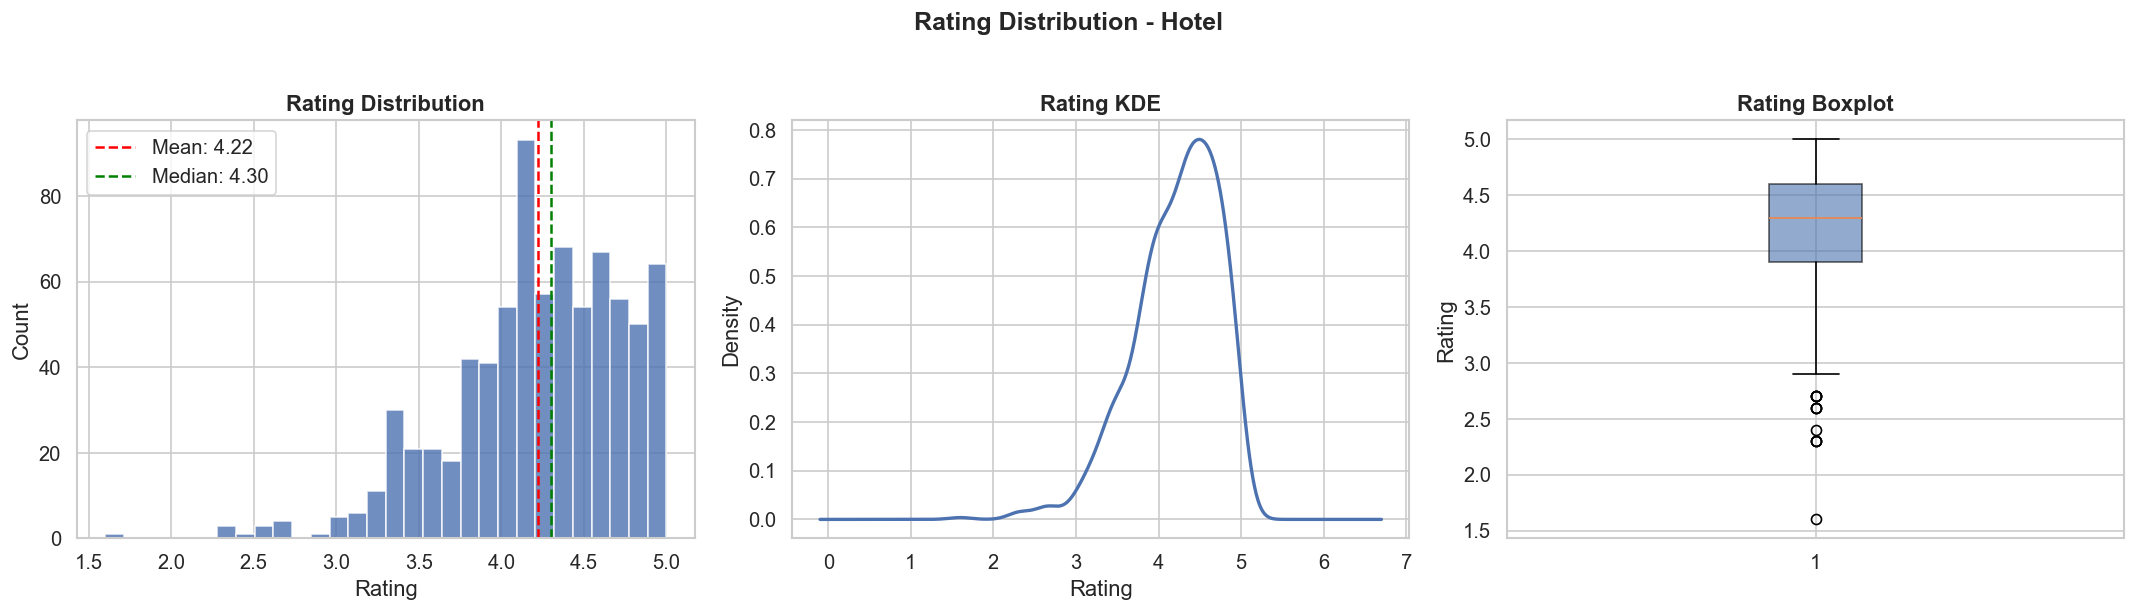

Rating Stats: mean=4.22, median=4.30, std=0.52, skew=-0.93


In [11]:
print('=' * 70)
print(f'  UNIVARIATE NUMERICAL: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df_hotel['rating'].dropna(), bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(df_hotel['rating'].mean(), color='red', linestyle='--', label=f"Mean: {df_hotel['rating'].mean():.2f}")
axes[0].axvline(df_hotel['rating'].median(), color='green', linestyle='--', label=f"Median: {df_hotel['rating'].median():.2f}")
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# KDE
df_hotel['rating'].dropna().plot(kind='kde', ax=axes[1], color='#4C72B0', linewidth=2)
axes[1].set_title('Rating KDE', fontweight='bold')
axes[1].set_xlabel('Rating')

# Boxplot
axes[2].boxplot(df_hotel['rating'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[2].set_title('Rating Boxplot', fontweight='bold')
axes[2].set_ylabel('Rating')

plt.suptitle('Rating Distribution - Hotel', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/hotel_rating_distribution.png', bbox_inches='tight')
plt.show()

print(f"Rating Stats: mean={df_hotel['rating'].mean():.2f}, median={df_hotel['rating'].median():.2f}, "
      f"std={df_hotel['rating'].std():.2f}, skew={df_hotel['rating'].skew():.2f}")


  REVIEW COUNT ANALYSIS: HOTEL (771 places)


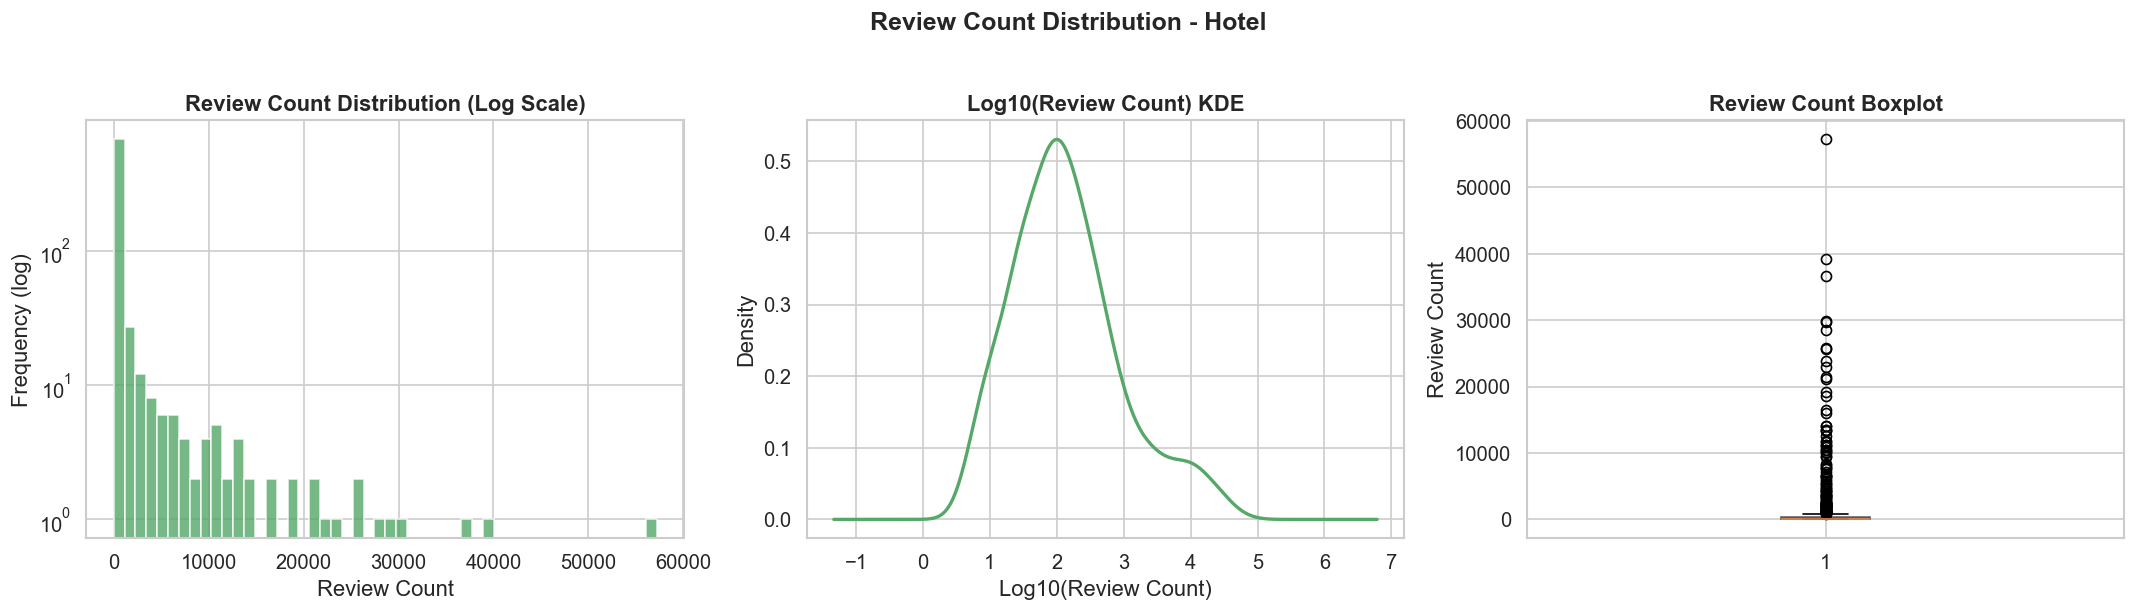

Review Stats: mean=1263, median=112, max=57,217, places with 0 reviews: 0


In [12]:
print('=' * 70)
print(f'  REVIEW COUNT ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

reviews = df_hotel['review_count'].dropna()
reviews_positive = reviews[reviews > 0]

axes[0].hist(reviews_positive, bins=50, color='#55A868', edgecolor='white', alpha=0.8, log=True)
axes[0].set_title('Review Count Distribution (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Review Count')
axes[0].set_ylabel('Frequency (log)')

log_reviews = np.log10(reviews_positive)
log_reviews.plot(kind='kde', ax=axes[1], color='#55A868', linewidth=2)
axes[1].set_title('Log10(Review Count) KDE', fontweight='bold')
axes[1].set_xlabel('Log10(Review Count)')

axes[2].boxplot(reviews_positive, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#55A868', alpha=0.6))
axes[2].set_title('Review Count Boxplot', fontweight='bold')
axes[2].set_ylabel('Review Count')

plt.suptitle('Review Count Distribution - Hotel', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/hotel_review_count_distribution.png', bbox_inches='tight')
plt.show()

print(f"Review Stats: mean={reviews.mean():.0f}, median={reviews.median():.0f}, "
      f"max={reviews.max():,}, places with 0 reviews: {(reviews == 0).sum()}")

# ---
# ## 6. Univariate Analysis - Categorical / Subcategory Variables


  SUBCATEGORY DISTRIBUTION: HOTEL (771 places)


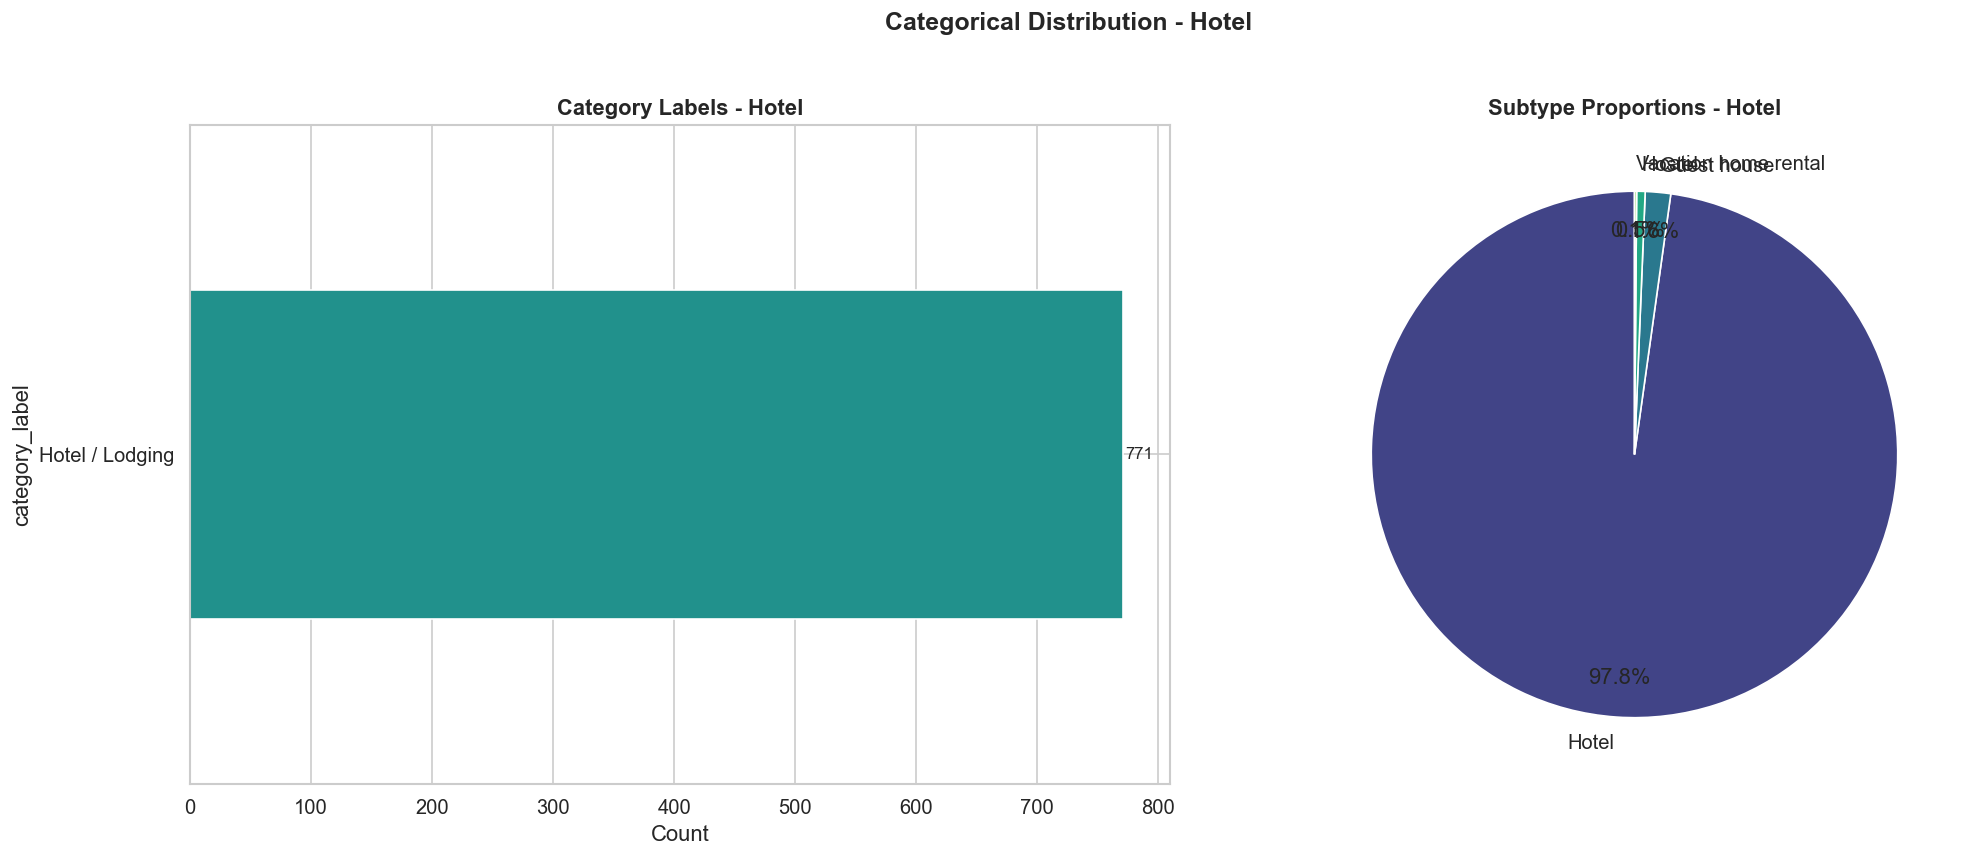


Category Label Counts (hotel):
  Hotel / Lodging                            771 (100.0%)

Subtype Counts (hotel):
  Hotel                                      754 (97.8%)
  Guest house                                 12 (1.6%)
  Hostel                                       4 (0.5%)
  Vacation home rental                         1 (0.1%)


In [13]:
print('=' * 70)
print(f'  SUBCATEGORY DISTRIBUTION: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Category label distribution
if 'category_label' in df_hotel.columns:
    label_counts = df_hotel['category_label'].value_counts()
    label_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(label_counts)))
    axes[0].set_title('Category Labels - Hotel', fontweight='bold')
    axes[0].set_xlabel('Count')
    for i, v in enumerate(label_counts.values):
        axes[0].text(v + 2, i, f'{v:,}', va='center', fontsize=10)

# Subtype distribution
if 'subtype' in df_hotel.columns:
    subtype_counts = df_hotel['subtype'].dropna().value_counts()
    if len(subtype_counts) > 0:
        top_n = 10
        top_subtypes = subtype_counts.head(top_n)
        other = subtype_counts[top_n:].sum() if len(subtype_counts) > top_n else 0
        pie_data = pd.concat([top_subtypes, pd.Series({'Other': other})]) if other > 0 else top_subtypes
        colors = sns.color_palette('viridis', len(pie_data))
        axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
                    colors=colors, startangle=90, pctdistance=0.85)
        axes[1].set_title('Subtype Proportions - Hotel', fontweight='bold')

plt.suptitle('Categorical Distribution - Hotel', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/hotel_category_distribution.png', bbox_inches='tight')
plt.show()

print('\nCategory Label Counts (hotel):')
if 'category_label' in df_hotel.columns:
    for label, count in df_hotel['category_label'].value_counts().items():
        print(f'  {label:40s} {count:>5,} ({count/len(df_hotel)*100:.1f}%)')

if 'subtype' in df_hotel.columns:
    print('\nSubtype Counts (hotel):')
    for st, count in df_hotel['subtype'].value_counts().head(15).items():
        print(f'  {str(st):40s} {count:>5,} ({count/len(df_hotel)*100:.1f}%)')


District distribution


  DISTRICT DISTRIBUTION: HOTEL (771 places)


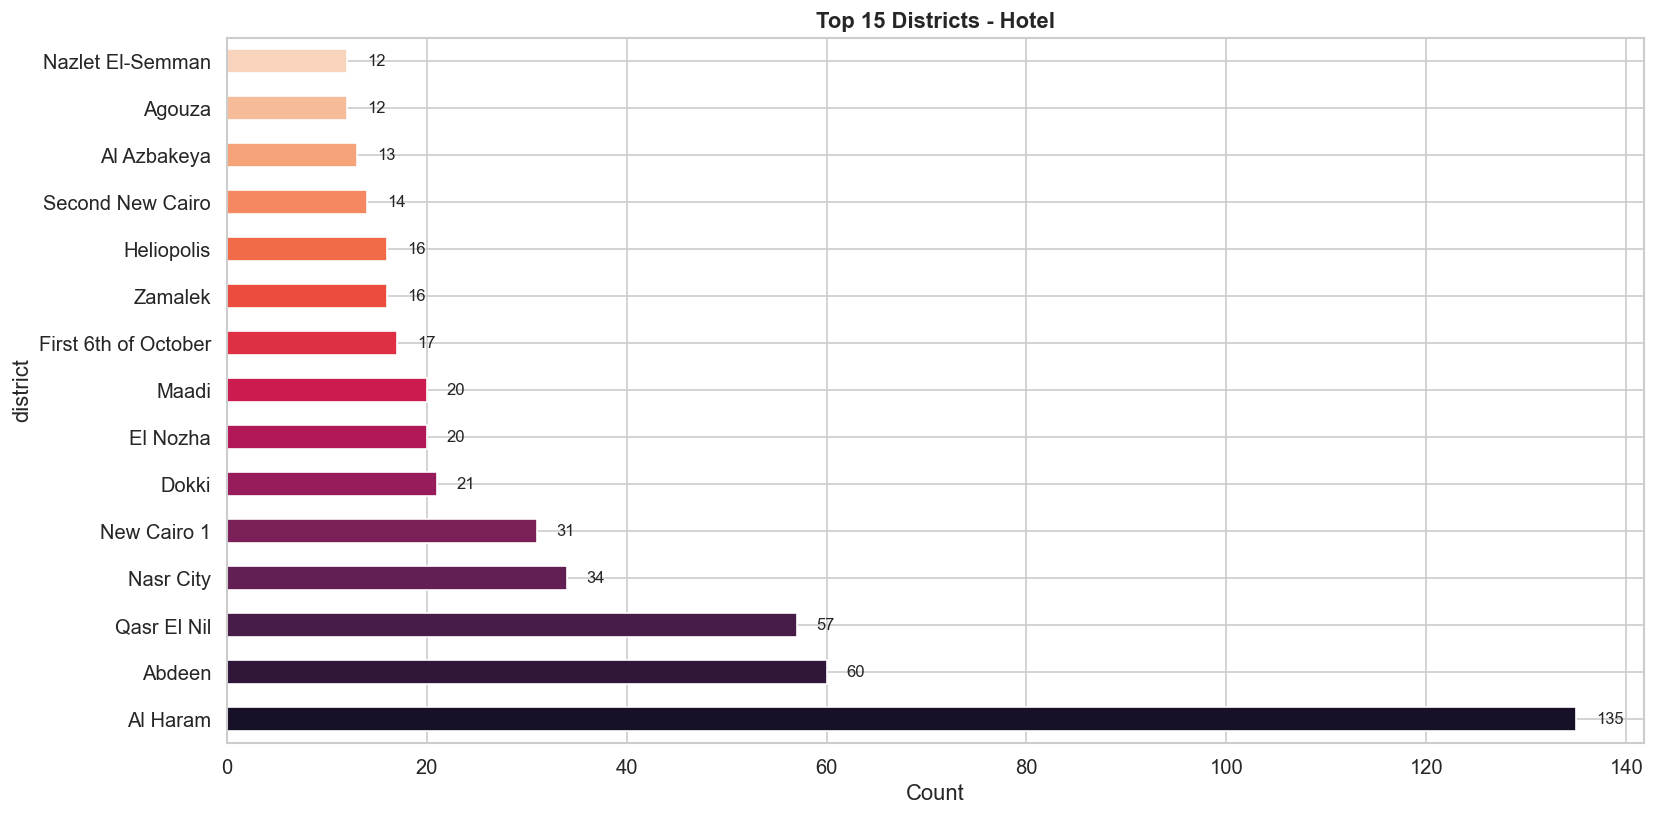

In [14]:
print('=' * 70)
print(f'  DISTRICT DISTRIBUTION: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

dist_counts = df_hotel['district'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 7))
dist_counts.plot(kind='barh', ax=ax, color=sns.color_palette('rocket', len(dist_counts)))
ax.set_title('Top 15 Districts - Hotel', fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(dist_counts.values):
    ax.text(v + 2, i, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/hotel_district_distribution.png', bbox_inches='tight')
plt.show()

# ---
# ## 7. Geographical Analysis


In [15]:
cairo_center = [df_hotel['lat'].median(), df_hotel['lon'].median()]

print('=' * 70)
print(f'  GEOGRAPHICAL ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

# Interactive Folium map
sample_size = min(2000, len(df_hotel))
df_sample = df_hotel.sample(n=sample_size, random_state=42)

m = folium.Map(location=cairo_center, zoom_start=12, tiles='CartoDB positron')
marker_cluster = MarkerCluster().add_to(m)

for _, row in df_sample.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4, color='#4C72B0', fill=True, fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>"
            f"Category: Hotel<br>"
            f"Rating: {row.get('rating', 'N/A')}<br>"
            f"Reviews: {row.get('review_count', 0):,}",
            max_width=250
        ),
    ).add_to(marker_cluster)

m.save('../outputs/figures/hotel_places_map.html')
print(f'Interactive map saved: outputs/figures/hotel_places_map.html ({sample_size:,} places)')

# Heatmap
m_heat = folium.Map(location=cairo_center, zoom_start=12, tiles='CartoDB positron')
heat_data = df_hotel[['lat', 'lon']].dropna().values.tolist()
HeatMap(heat_data, radius=15, blur=20, max_zoom=13).add_to(m_heat)
m_heat.save('../outputs/figures/hotel_density_heatmap.html')
print('Density heatmap saved: outputs/figures/hotel_density_heatmap.html')

# High-rated places map
high_rated = df_hotel[df_hotel['rating'] >= 4.5]
if len(high_rated) > 0:
    high_rated_sample = high_rated.sample(min(1000, len(high_rated)), random_state=42)
    m_hr = folium.Map(location=cairo_center, zoom_start=12, tiles='CartoDB positron')
    for _, row in high_rated_sample.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5, color='gold', fill=True, fill_opacity=0.8,
            popup=f"<b>{row['name']}</b><br>Rating: {row['rating']}<br>Reviews: {row.get('review_count', 0):,}",
        ).add_to(m_hr)
    m_hr.save('../outputs/figures/hotel_high_rated_map.html')
    print(f'High-rated places map saved ({len(high_rated_sample):,} places)')

# Static scatter map with Plotly
fig = px.scatter_mapbox(
    df_hotel.sample(min(2000, len(df_hotel)), random_state=42),
    lat='lat', lon='lon',
    size='review_count', size_max=15,
    hover_name='name',
    hover_data={'rating': True, 'review_count': True},
    mapbox_style='carto-positron',
    center={'lat': cairo_center[0], 'lon': cairo_center[1]},
    zoom=11, title='Hotels - Geographic Distribution', height=600,
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.write_html('../outputs/figures/hotel_plotly_map.html')
print('Plotly map saved: outputs/figures/hotel_plotly_map.html')

# ---
# ## 8. Rating & Review Analysis


  GEOGRAPHICAL ANALYSIS: HOTEL (771 places)
Interactive map saved: outputs/figures/hotel_places_map.html (771 places)
Density heatmap saved: outputs/figures/hotel_density_heatmap.html
High-rated places map saved (291 places)
Plotly map saved: outputs/figures/hotel_plotly_map.html


  RATING & REVIEW ANALYSIS: HOTEL (771 places)

Top 10 Most Reviewed Hotels:
                                   name  rating  review_count                                                                              address
InterContinental Cairo Semiramis by IHG   4.800         57217                 Nile Corniche, Qasr Ad Dobarah, Qasr El Nil, Cairo Governorate 11511
          Sofitel Cairo Nile El Gezirah   4.800         39192                    3 El Thawra Council St Zamalek, El Orman, Cairo Governorate 11518
InterContinental Citystars Cairo by IHG   4.700         36682                      Omar Ibn El-Khattab, Street, Nasr City, Cairo Governorate 11737
                  Novotel Cairo Airport   4.600         29887                  Cairo Airport, Sheraton Al Matar, El Nozha, Cairo Governorate 11776
                          Ramses Hilton   4.200         29736                          1115 Nile Corniche, Sharkas, Bulaq, Cairo Governorate 12344
   Holiday Inn Cairo - Citystars by IHG  

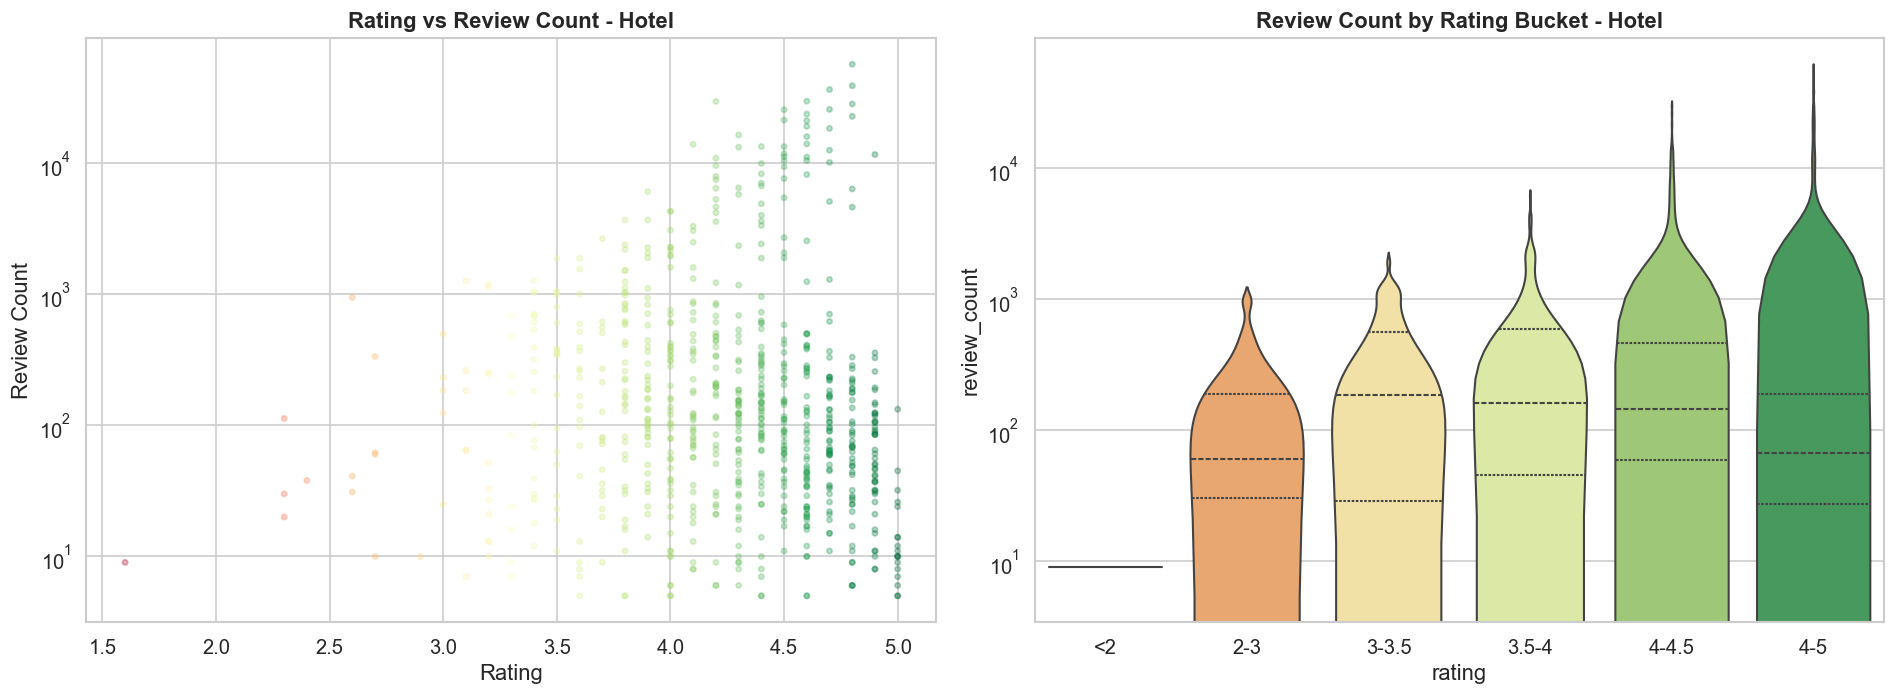


Rating Stats: mean=4.22, median=4.30, std=0.52
Review Stats: mean=1263, median=112, max=57,217


In [16]:
print('=' * 70)
print(f'  RATING & REVIEW ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

# Top reviewed
top_reviewed = df_hotel.nlargest(10, 'review_count')[['name', 'rating', 'review_count', 'address']]
print('\nTop 10 Most Reviewed Hotels:')
print(top_reviewed.to_string(index=False))

# Rating vs Review Count scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df_hotel['rating'], df_hotel['review_count'], alpha=0.3, s=10, c=df_hotel['rating'], cmap='RdYlGn')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Review Count')
axes[0].set_title('Rating vs Review Count - Hotel', fontweight='bold')
axes[0].set_yscale('log')

rating_bucket = pd.cut(df_hotel['rating'], bins=[0, 2, 3, 3.5, 4, 4.5, 5],
                       labels=['<2', '2-3', '3-3.5', '3.5-4', '4-4.5', '4-5'])
valid_mask = rating_bucket.notna()
if valid_mask.sum() > 0:
    sns.violinplot(x=rating_bucket[valid_mask], y=df_hotel.loc[valid_mask, 'review_count'], ax=axes[1],
                   palette='RdYlGn', inner='quartile')
axes[1].set_title('Review Count by Rating Bucket - Hotel', fontweight='bold')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../outputs/figures/hotel_rating_vs_reviews.png', bbox_inches='tight')
plt.show()

print(f"\nRating Stats: mean={df_hotel['rating'].mean():.2f}, median={df_hotel['rating'].median():.2f}, "
      f"std={df_hotel['rating'].std():.2f}")
print(f"Review Stats: mean={df_hotel['review_count'].mean():.0f}, median={df_hotel['review_count'].median():.0f}, "
      f"max={df_hotel['review_count'].max():,}")

# ---
# ## 9. Popularity Analysis


  POPULARITY ANALYSIS: HOTEL (771 places)
Popularity score computed (0-1 scale)
   Mean: 0.601
   Std:  0.120

Top 10 Most Popular Hotels:
                                   name  rating  review_count  popularity_score
InterContinental Cairo Semiramis by IHG   4.800         57217             0.965
          Sofitel Cairo Nile El Gezirah   4.800         39192             0.948
   Holiday Inn Cairo - Citystars by IHG   4.800         28454             0.934
InterContinental Citystars Cairo by IHG   4.700         36682             0.928
    Steigenberger Hotel El Tahrir Cairo   4.800         22889             0.925
        Crowne Plaza West Cairo - Arkan   4.900         11712             0.913
               Fairmont Nile City Hotel   4.700         25857             0.912
                  Novotel Cairo Airport   4.600         29887             0.901
 Four Seasons Hotel Cairo at Nile Plaza   4.700         18516             0.898
                 Kempinski Palace Cairo   4.600         23830

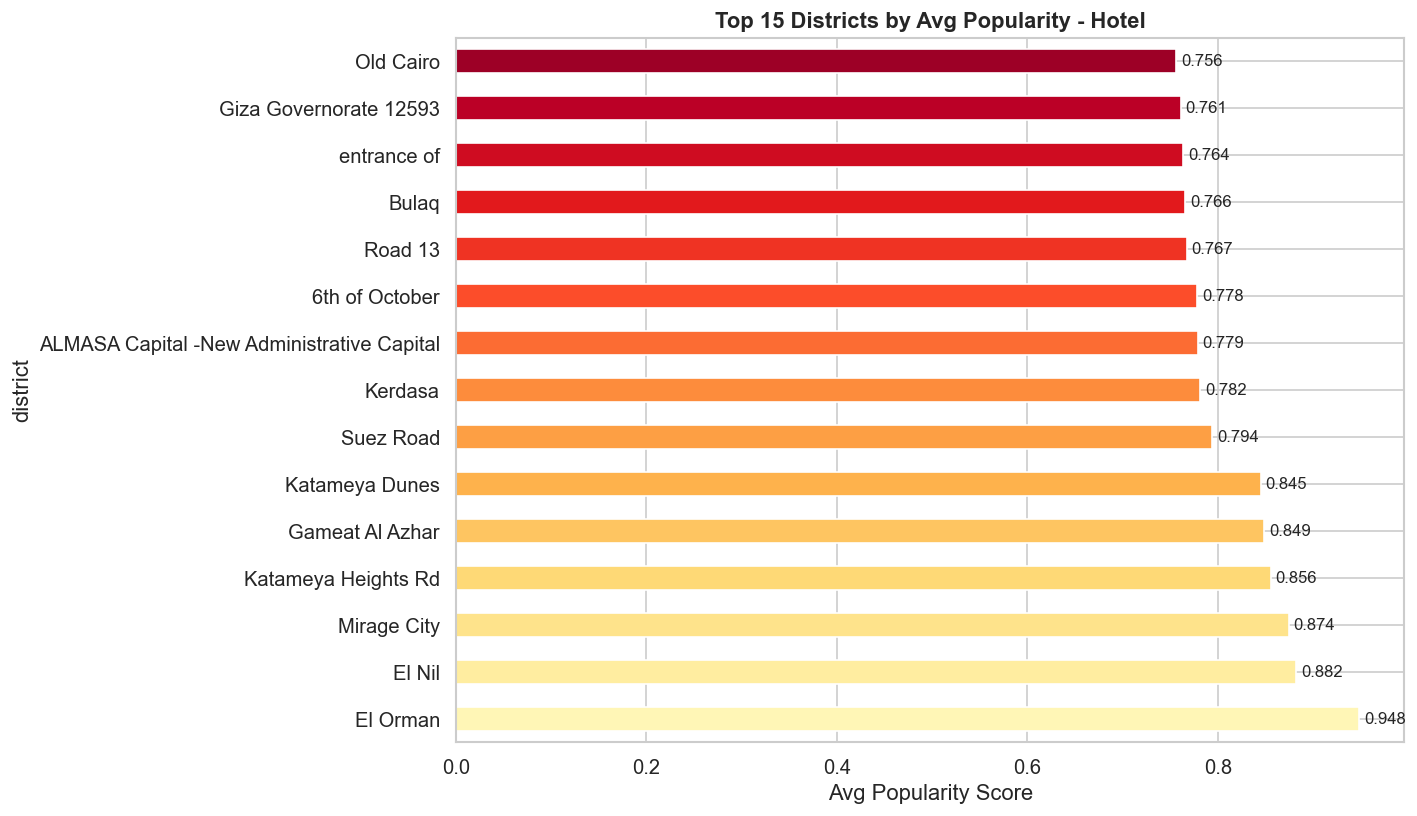

In [17]:
print('=' * 70)
print(f'  POPULARITY ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

df_hotel = compute_popularity(df_hotel)

print(f"Popularity score computed (0-1 scale)")
print(f"   Mean: {df_hotel['popularity_score'].mean():.3f}")
print(f"   Std:  {df_hotel['popularity_score'].std():.3f}")

# Top popular
top_popular = df_hotel.nlargest(10, 'popularity_score')[['name', 'rating', 'review_count', 'popularity_score']]
print('\nTop 10 Most Popular Hotels:')
print(top_popular.to_string(index=False))

# District popularity
dist_pop = df_hotel.groupby('district').agg(
    avg_popularity=('popularity_score', 'mean'),
    count=('name', 'count'),
    avg_rating=('rating', 'mean')
).sort_values('avg_popularity', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
dist_pop['avg_popularity'].plot(kind='barh', ax=ax, color=sns.color_palette('YlOrRd', len(dist_pop)))
ax.set_title('Top 15 Districts by Avg Popularity - Hotel', fontweight='bold')
ax.set_xlabel('Avg Popularity Score')
for i, v in enumerate(dist_pop['avg_popularity'].values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/hotel_district_popularity.png', bbox_inches='tight')
plt.show()

# ---
# ## 10. Location Intelligence


  LOCATION INTELLIGENCE: HOTEL (771 places)

Significant Areas for Hotels (>=3 places):
                      num_places  avg_rating  total_reviews  avg_popularity
area                                                                       
Al Haram                     139       4.360          57463           0.610
Abdeen                        61       4.010          12312           0.550
Qasr El Nil                   57       4.130         121574           0.580
Nasr City                     34       4.260         123719           0.640
New Cairo 1                   31       4.530          11081           0.620
Dokki                         21       3.940          47088           0.610
Maadi                         21       4.070          14792           0.580
El Nozha                      21       4.220         108995           0.680
First 6th of October          17       4.330          21796           0.640
Heliopolis                    16       3.840          19334           0.530


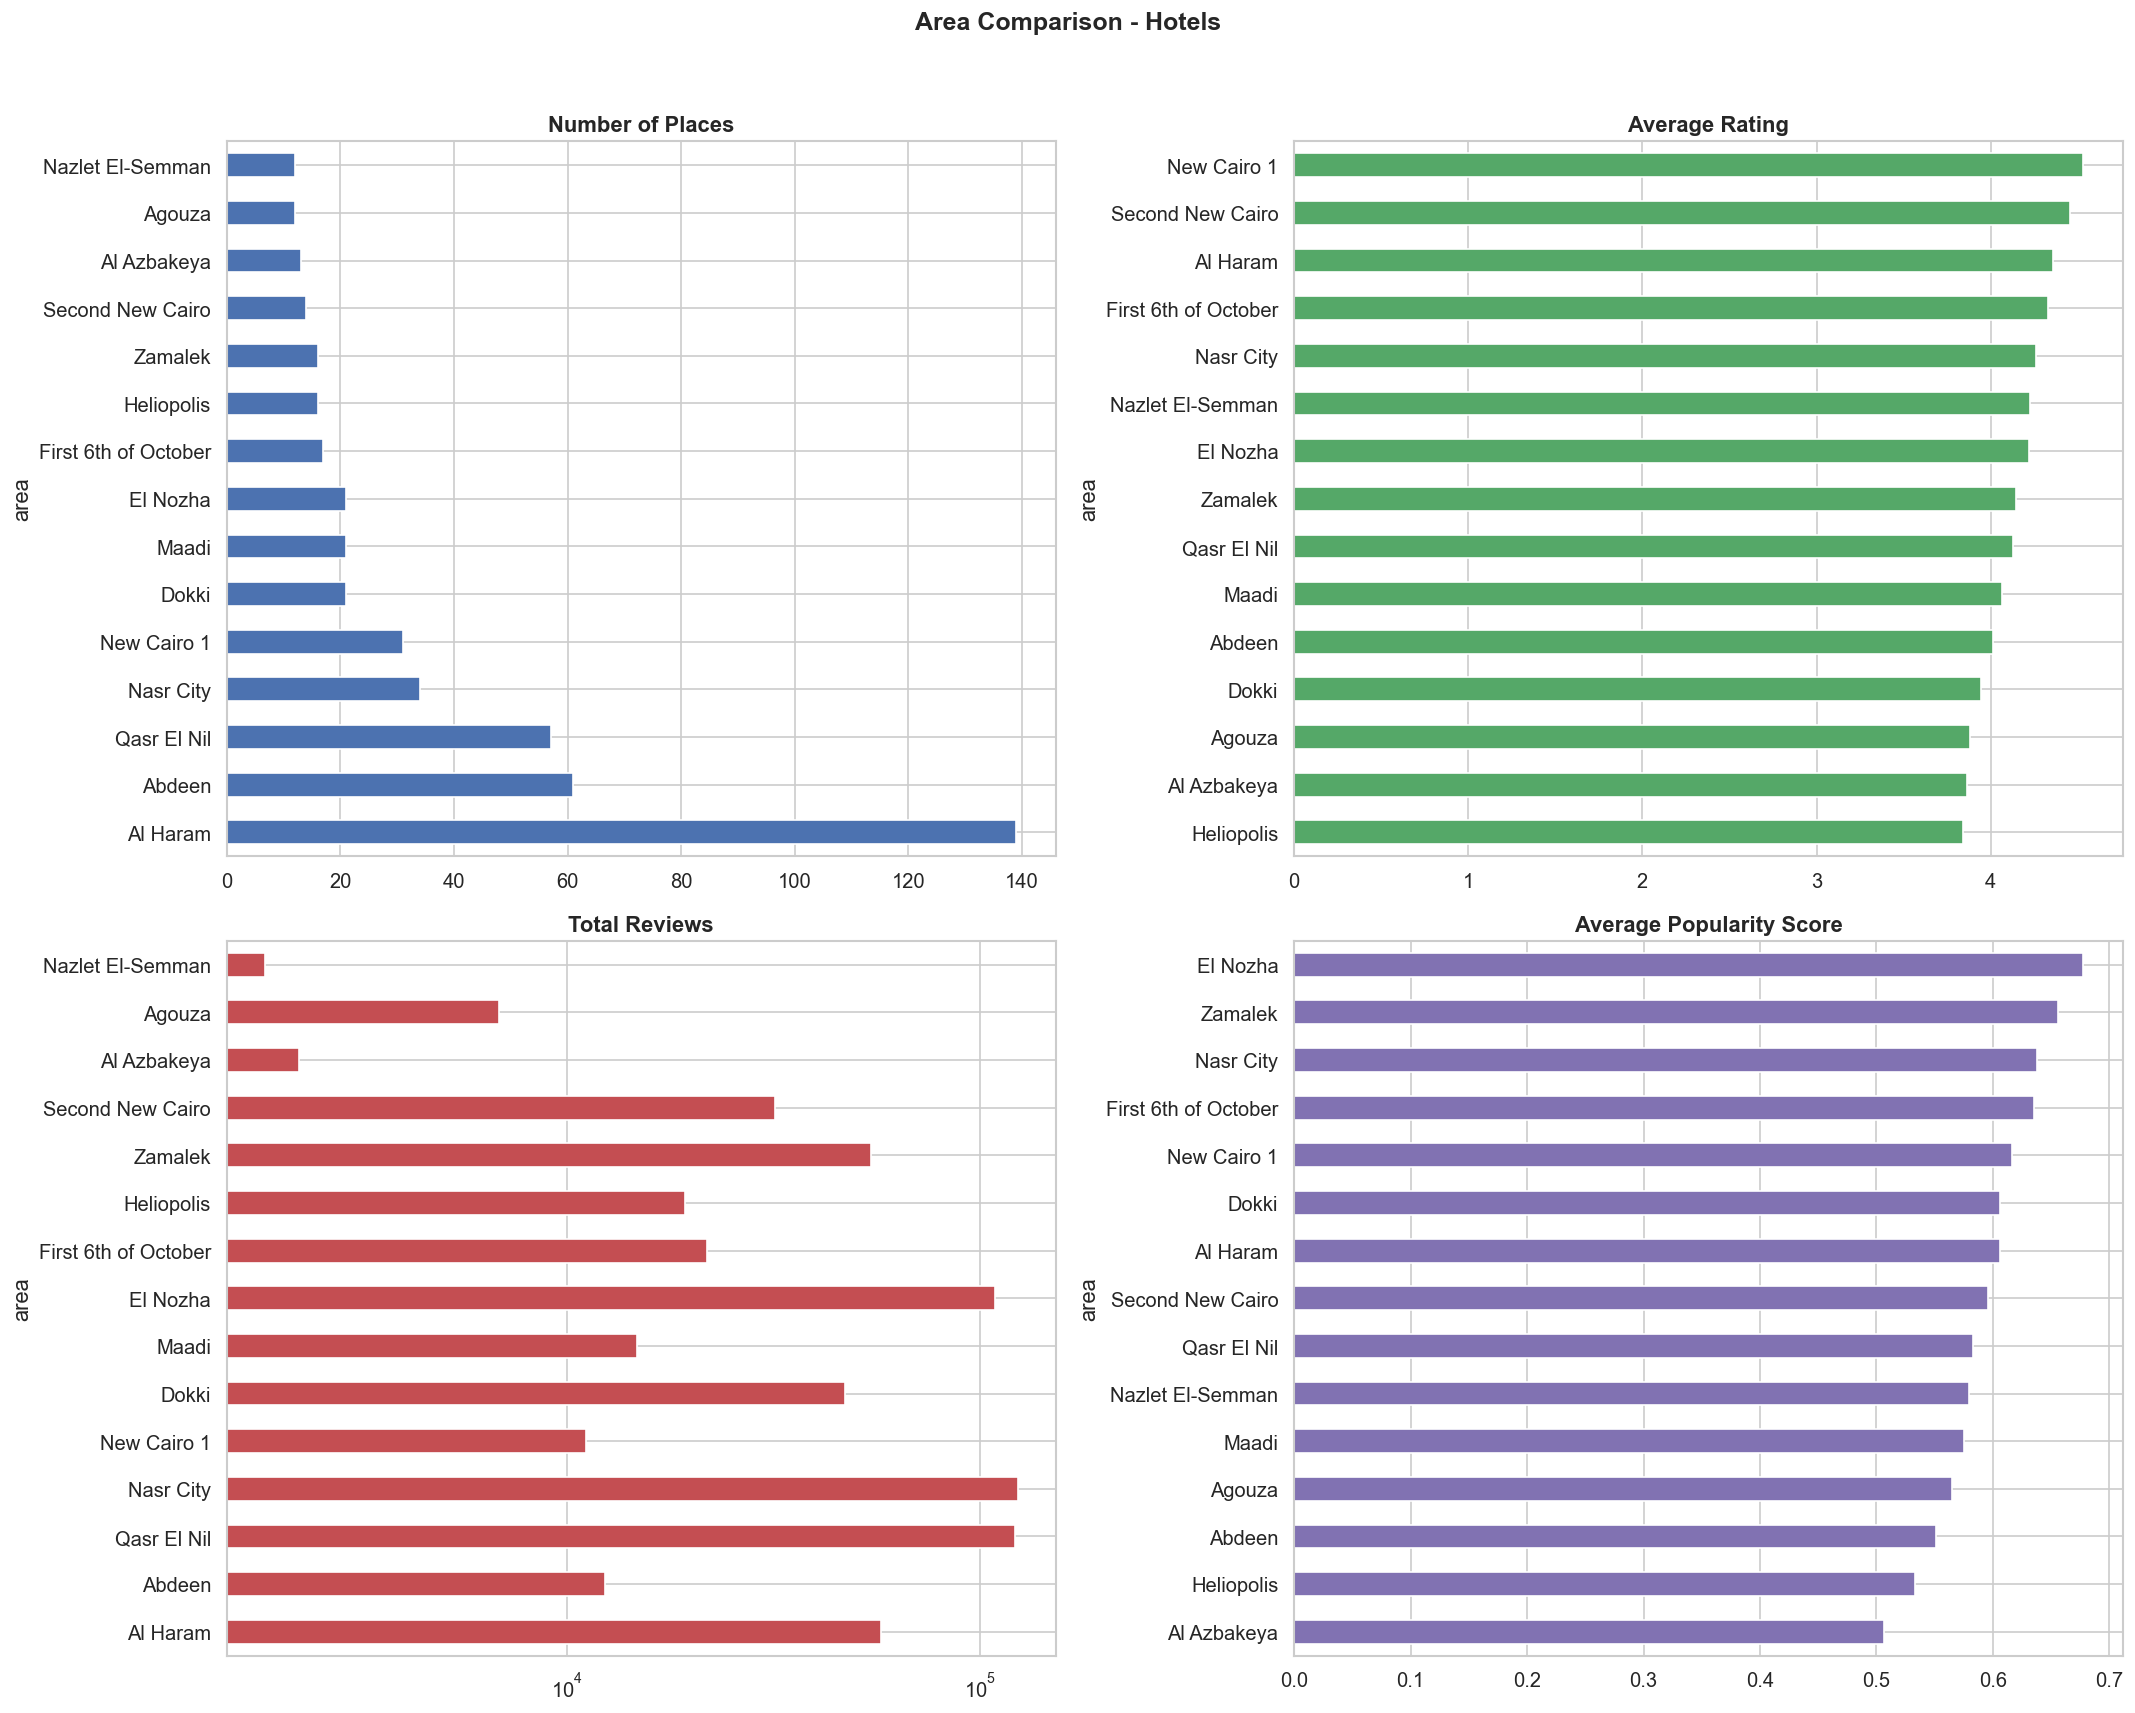

In [18]:
print('=' * 70)
print(f'  LOCATION INTELLIGENCE: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

area_stats = df_hotel.groupby('area').agg(
    num_places=('name', 'count'),
    avg_rating=('rating', 'mean'),
    total_reviews=('review_count', 'sum'),
    avg_popularity=('popularity_score', 'mean')
).sort_values('num_places', ascending=False)

significant_areas = area_stats[area_stats['num_places'] >= 3].head(15)
print(f'\nSignificant Areas for Hotels (>=3 places):')
print(significant_areas.round(2).to_string())

if len(significant_areas) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    significant_areas['num_places'].plot(kind='barh', ax=axes[0, 0], color='#4C72B0')
    axes[0, 0].set_title('Number of Places', fontweight='bold')

    significant_areas.sort_values('avg_rating').plot(kind='barh', y='avg_rating', ax=axes[0, 1],
                                                      color='#55A868', legend=False)
    axes[0, 1].set_title('Average Rating', fontweight='bold')

    significant_areas['total_reviews'].plot(kind='barh', ax=axes[1, 0], color='#C44E52')
    axes[1, 0].set_title('Total Reviews', fontweight='bold')
    axes[1, 0].set_xscale('log')

    significant_areas.sort_values('avg_popularity').plot(kind='barh', y='avg_popularity', ax=axes[1, 1],
                                                          color='#8172B2', legend=False)
    axes[1, 1].set_title('Average Popularity Score', fontweight='bold')

    plt.suptitle('Area Comparison - Hotels', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/hotel_area_comparison.png', bbox_inches='tight')
    plt.show()

# ---
# ## 11. Correlation Analysis


  CORRELATION ANALYSIS: HOTEL (771 places)


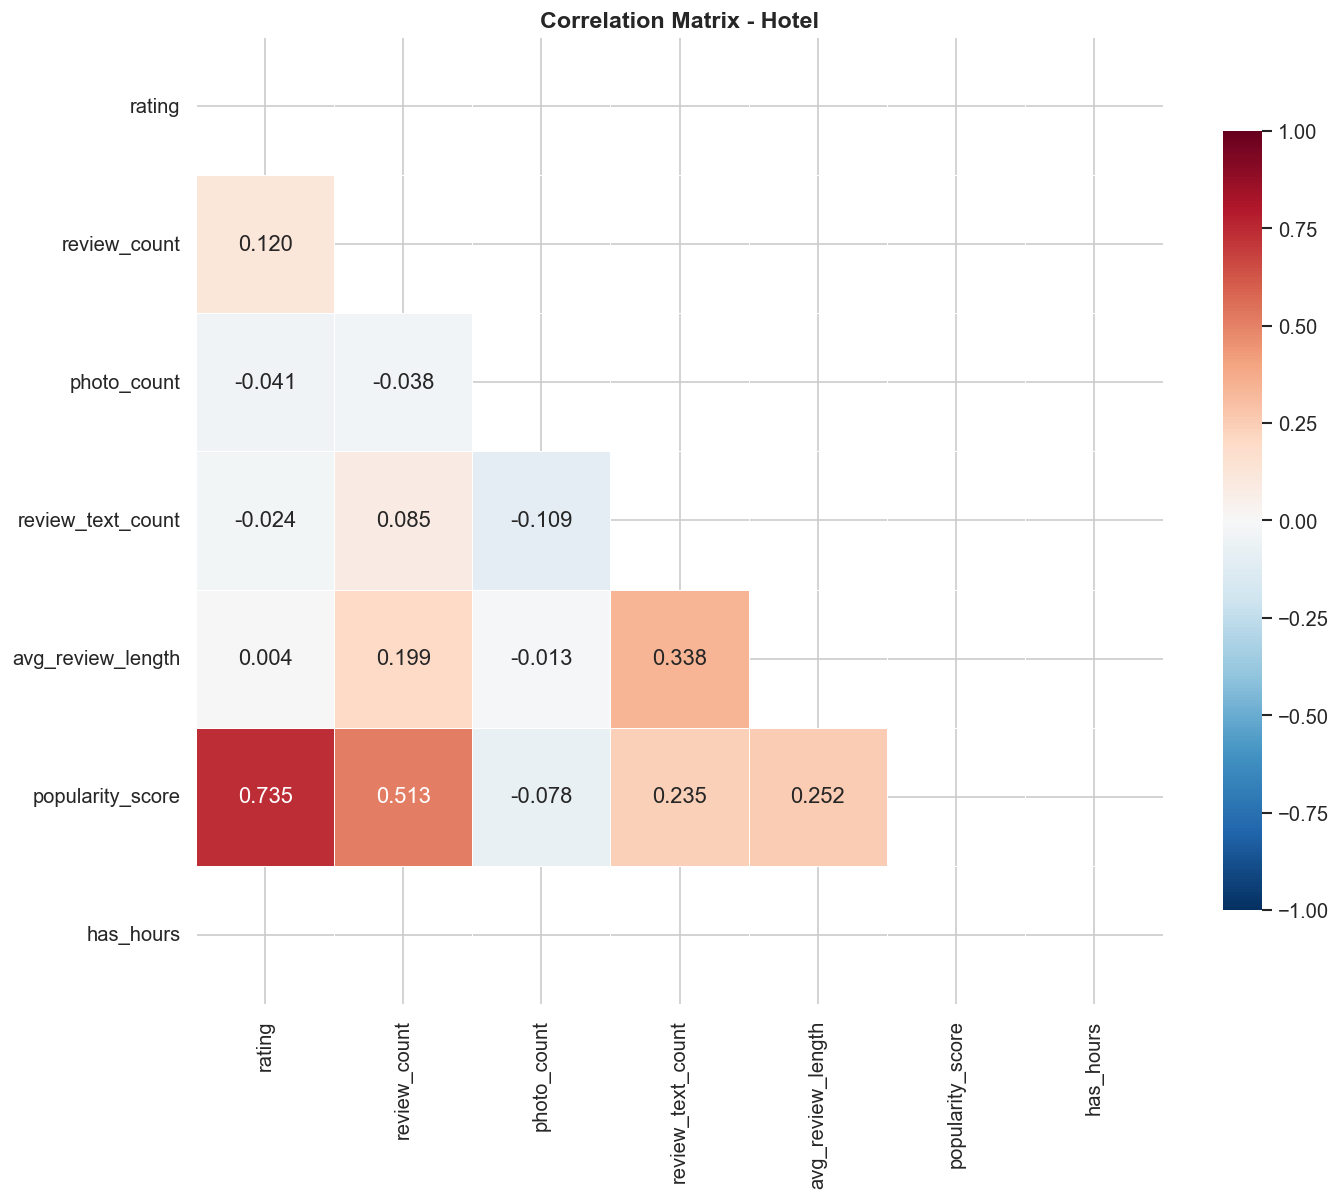

Key Correlations (hotel):
  rating               x review_count        : r = +0.120
  rating               x photo_count         : r = -0.041
  review_count         x photo_count         : r = -0.038


In [19]:
print('=' * 70)
print(f'  CORRELATION ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

corr_cols = ['rating', 'review_count', 'photo_count', 'review_text_count',
             'avg_review_length', 'popularity_score', 'has_hours']
corr_cols = [c for c in corr_cols if c in df_hotel.columns]

corr_matrix = df_hotel[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix - Hotel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/hotel_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Key Correlations (hotel):')
for pair in [('rating', 'review_count'), ('rating', 'photo_count'), ('review_count', 'photo_count')]:
    if pair[0] in df_hotel.columns and pair[1] in df_hotel.columns:
        corr = df_hotel[pair[0]].corr(df_hotel[pair[1]])
        print(f"  {pair[0]:20s} x {pair[1]:20s}: r = {corr:+.3f}")

# ---
# ## 12. Outlier Detection


  OUTLIER DETECTION: HOTEL (771 places)
IQR Outlier Detection (hotel):
  review_count: Q1=36.0, Q3=372.5, IQR=336.5, bounds=[-468.8, 877.2], outliers=114
  rating: Q1=3.9, Q3=4.6, IQR=0.7, bounds=[2.9, 5.6], outliers=12
Z-Score outliers (|z| > 3) in review_count: 16
   Max z-score: 12.46
   Min z-score: -0.28


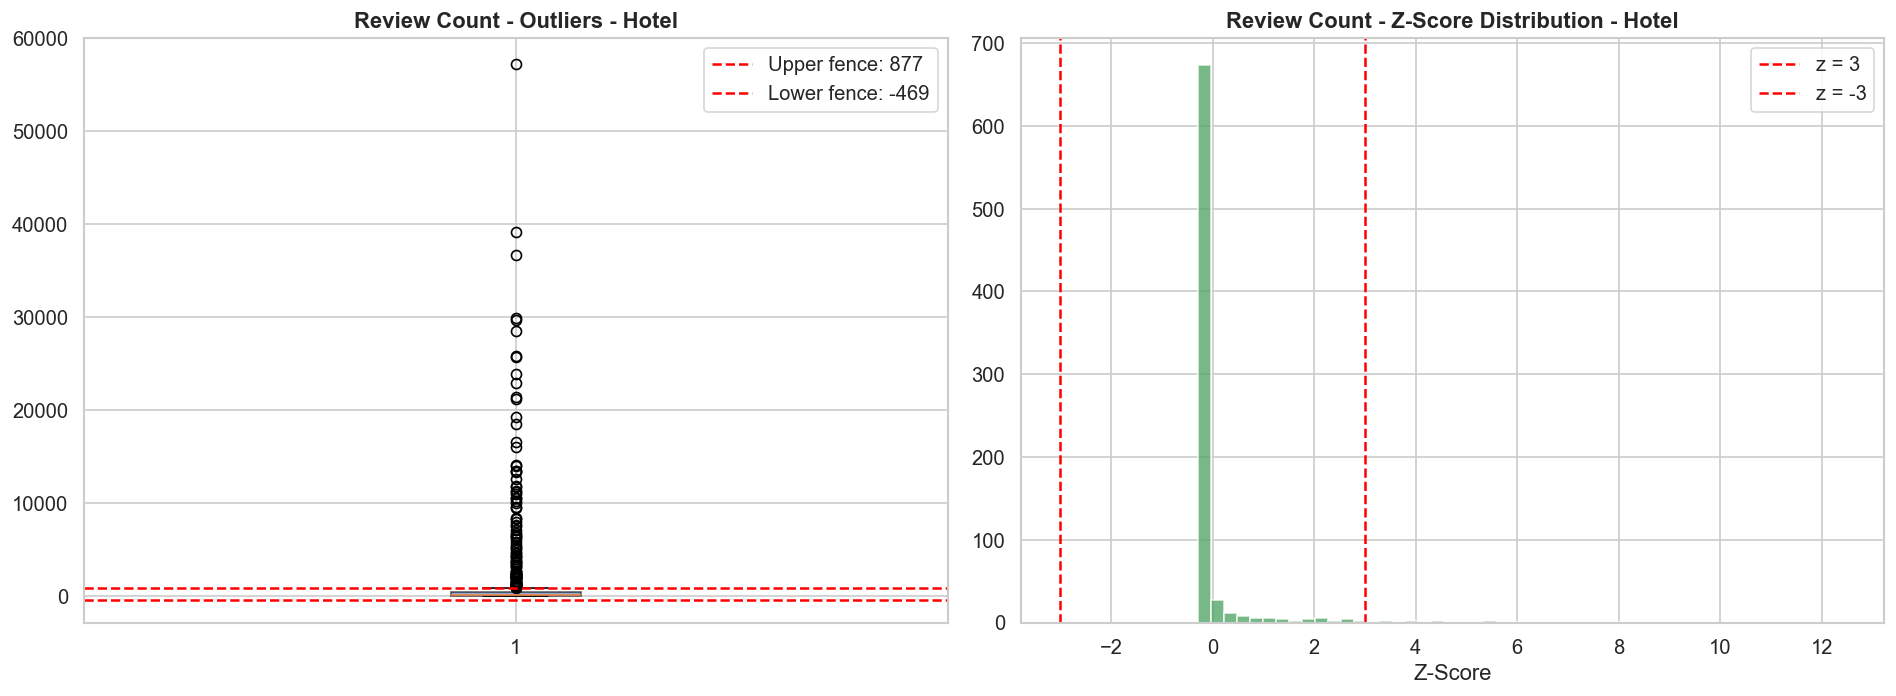

In [20]:
print('=' * 70)
print(f'  OUTLIER DETECTION: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

print('IQR Outlier Detection (hotel):')
detect_outliers_iqr(df_hotel['review_count'], 'review_count')
detect_outliers_iqr(df_hotel['rating'], 'rating')

# Z-score
df_hotel['review_zscore'] = zscore(df_hotel['review_count'].fillna(0))
z_outliers = df_hotel[df_hotel['review_zscore'].abs() > 3]
print(f"Z-Score outliers (|z| > 3) in review_count: {len(z_outliers):,}")
print(f"   Max z-score: {df_hotel['review_zscore'].max():.2f}")
print(f"   Min z-score: {df_hotel['review_zscore'].min():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

Q1, Q3 = df_hotel['review_count'].quantile(0.25), df_hotel['review_count'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

axes[0].boxplot(df_hotel['review_count'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[0].axhline(upper, color='red', linestyle='--', label=f'Upper fence: {upper:,.0f}')
axes[0].axhline(lower, color='red', linestyle='--', label=f'Lower fence: {lower:,.0f}')
axes[0].set_title('Review Count - Outliers - Hotel', fontweight='bold')
axes[0].legend()

axes[1].hist(df_hotel['review_zscore'].dropna(), bins=50, color='#55A868', edgecolor='white', alpha=0.8)
axes[1].axvline(3, color='red', linestyle='--', label='z = 3')
axes[1].axvline(-3, color='red', linestyle='--', label='z = -3')
axes[1].set_title('Review Count - Z-Score Distribution - Hotel', fontweight='bold')
axes[1].set_xlabel('Z-Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/hotel_outlier_detection.png', bbox_inches='tight')
plt.show()

df_hotel.drop(columns=['review_zscore'], inplace=True)

# ---
# ## 13. Tourism Insights


In [21]:
print('=' * 70)
print(f'  TOURISM INSIGHTS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

print('\nRating Distribution (hotel):')
for rating, count in df_hotel['rating'].value_counts().head(5).items():
    print(f"  Rating {rating}: {count:,} places ({count/len(df_hotel)*100:.1f}%)")

print('\nHighest-Engagement Districts (hotel):')
top_areas = df_hotel.groupby('district')['review_count'].sum().sort_values(ascending=False).head(5)
for area, reviews in top_areas.items():
    print(f"  {area}: {reviews:,.0f} total reviews")

hidden_gems = df_hotel[(df_hotel['rating'] >= 4.5) & (df_hotel['review_count'] < df_hotel['review_count'].quantile(0.25))]
print(f"\nHidden Gems (rating >= 4.5, low reviews): {len(hidden_gems):,} hotels")
if len(hidden_gems) > 0:
    print('Top hidden gems:')
    for _, row in hidden_gems.nlargest(5, 'rating').iterrows():
        print(f"  Rating: {row['rating']:.1f} - {row['name']} ({row['review_count']:,} reviews)")

# Recommendation candidates
print('\nTop Recommendation Candidates (hotel):')
top_recs = df_hotel.nlargest(10, 'rating')[['name', 'rating', 'review_count', 'popularity_score']]
print(top_recs.to_string(index=False))

# ---
# ## 14. Recommendation-Oriented Features


  TOURISM INSIGHTS: HOTEL (771 places)

Rating Distribution (hotel):
  Rating 4.4: 68 places (8.8%)
  Rating 4.6: 67 places (8.7%)
  Rating 4.3: 57 places (7.4%)
  Rating 4.7: 56 places (7.3%)
  Rating 4.5: 54 places (7.0%)

Highest-Engagement Districts (hotel):
  Nasr City: 123,719 total reviews
  Qasr El Nil: 121,574 total reviews
  El Nozha: 99,554 total reviews
  Bulaq: 67,740 total reviews
  Al Haram: 56,980 total reviews

Hidden Gems (rating >= 4.5, low reviews): 84 hotels
Top hidden gems:
  Rating: 5.0 - Welhome Stays Aparthotel (32 reviews)
  Rating: 5.0 - Alshemy serviced Apartments (26 reviews)
  Rating: 5.0 - Rafiki Hostels - Pyramids (24 reviews)
  Rating: 5.0 - Space Hostel (14 reviews)
  Rating: 5.0 - M Residence (14 reviews)

Top Recommendation Candidates (hotel):
                       name  rating  review_count  popularity_score
 ONE GATE Pyramids View INN   5.000           133             0.736
         Eyad Pyramids View   5.000            45             0.689
   Wel

In [22]:
print('=' * 70)
print(f'  RECOMMENDATION SCORES: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

df_hotel = compute_recommendation_scores(df_hotel)

score_cols = ['family_friendly_score', 'budget_score', 'luxury_score']
print('\nRecommendation Feature Scores (hotel):')
print(df_hotel[score_cols].describe().round(3).to_string())

# Top recommendations by profile
print('\nTop 5 Recommendations by Profile (hotel):')
profiles = {
    'Family Trip': 'family_friendly_score',
    'Budget Traveler': 'budget_score',
    'Luxury Seeker': 'luxury_score',
}
for profile, score_col in profiles.items():
    top = df_hotel.nlargest(5, score_col)[['name', 'rating', 'review_count', score_col]]
    print(f"\n  {profile}:")
    for _, row in top.iterrows():
        print(f"    Rating: {row['rating']:.1f} | {row['name'][:45]:45s} | score={row[score_col]:.3f}")

# ---
# ## 15. Hotel-Specific Deep Dive

# ---
# ### 15a. Star Class Analysis


  RECOMMENDATION SCORES: HOTEL (771 places)

Recommendation Feature Scores (hotel):
       family_friendly_score  budget_score  luxury_score
count                771.000       771.000       771.000
mean                   0.558         0.838         0.736
std                    0.125         0.062         0.125
min                    0.028         0.700         0.283
25%                    0.496         0.789         0.648
50%                    0.558         0.833         0.743
75%                    0.622         0.885         0.835
max                    0.971         1.000         1.000

Top 5 Recommendations by Profile (hotel):

  Family Trip:
    Rating: 4.8 | InterContinental Cairo Semiramis by IHG       | score=0.971
    Rating: 4.8 | Sofitel Cairo Nile El Gezirah                 | score=0.950
    Rating: 4.8 | Holiday Inn Cairo - Citystars by IHG          | score=0.932
    Rating: 4.7 | InterContinental Citystars Cairo by IHG       | score=0.932
    Rating: 4.8 | Steigenberger 

  STAR CLASS ANALYSIS: HOTEL (771 places)
Hotels with star class data: 311 / 771 (40.3%)

Star Class Distribution:
  1-star: 15 (4.8%)
  2-star: 39 (12.5%)
  3-star: 126 (40.5%)
  4-star: 61 (19.6%)
  5-star: 70 (22.5%)


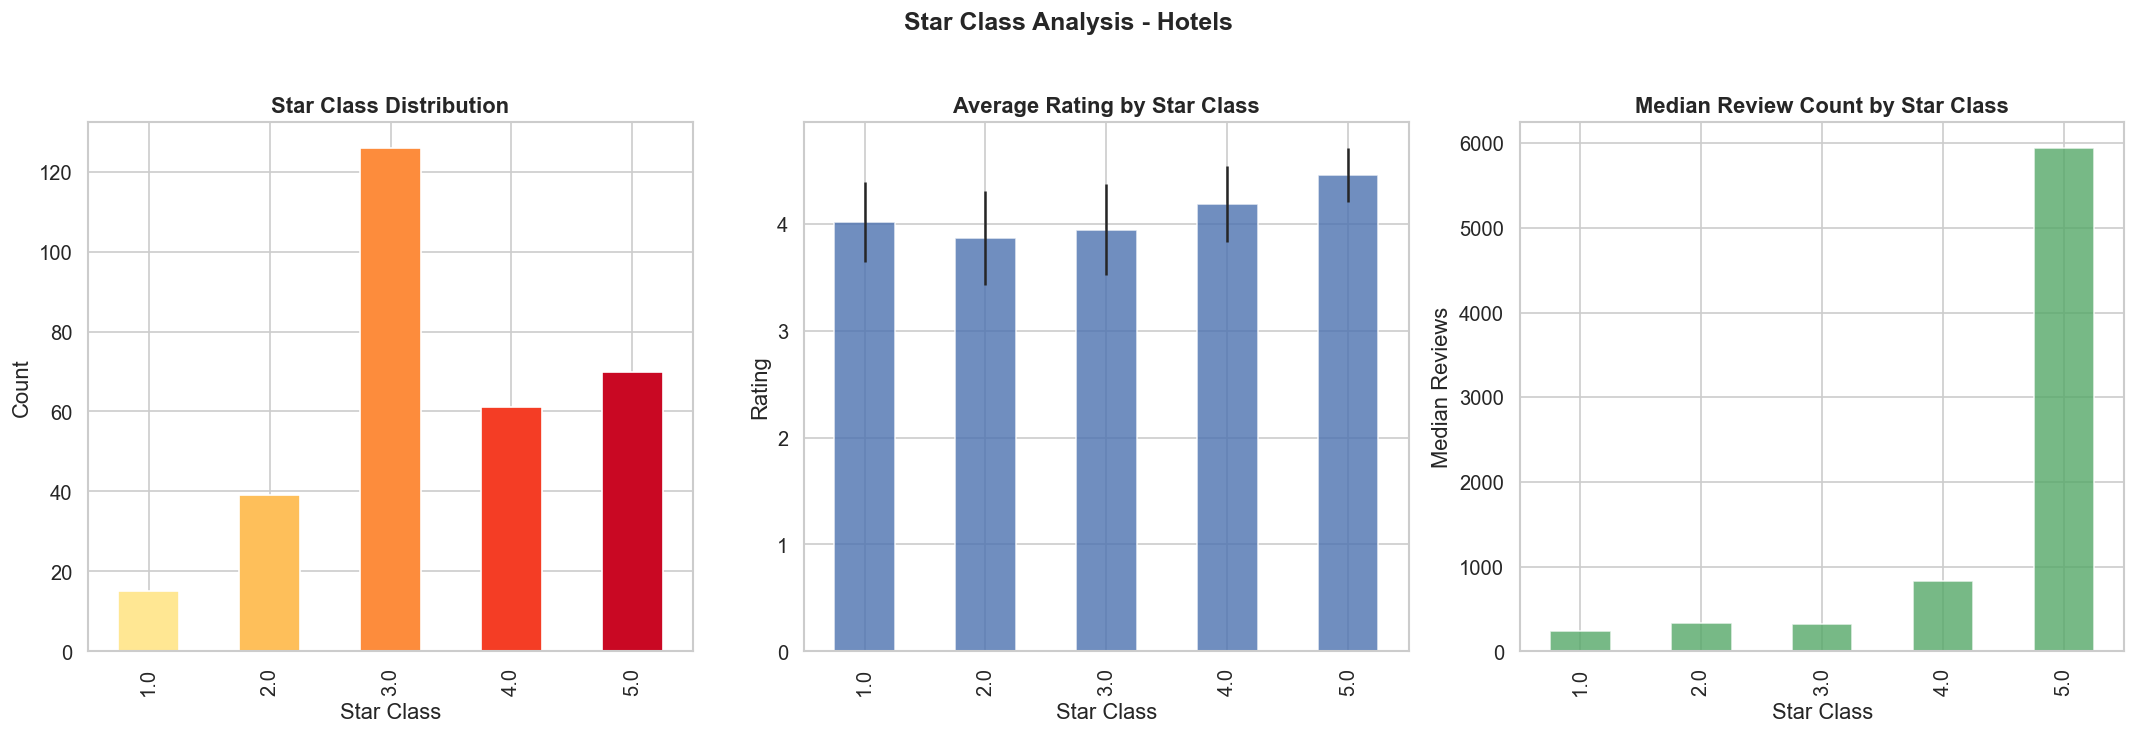


Star Class Stats:
           rating              review_count               
             mean median count         mean   median count
star_class                                                
1.000       4.020  4.000    15      288.470  238.000    15
2.000       3.870  3.900    39      468.820  330.000    39
3.000       3.950  4.000   126      573.060  325.000   126
4.000       4.190  4.200    61     3291.080  831.000    61
5.000       4.460  4.500    70     9057.760 5948.000    70


In [23]:
print('=' * 70)
print(f'  STAR CLASS ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

star_data = df_hotel[df_hotel['star_class'].notna()].copy()
print(f'Hotels with star class data: {len(star_data):,} / {len(df_hotel):,} ({len(star_data)/len(df_hotel)*100:.1f}%)')

if len(star_data) > 0:
    star_counts = star_data['star_class'].value_counts().sort_index()
    print(f'\nStar Class Distribution:')
    for stars, count in star_counts.items():
        print(f'  {int(stars)}-star: {count:,} ({count/len(star_data)*100:.1f}%)')

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Distribution
    star_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('YlOrRd', len(star_counts)))
    axes[0].set_title('Star Class Distribution', fontweight='bold')
    axes[0].set_xlabel('Star Class')
    axes[0].set_ylabel('Count')

    # Rating by star class
    star_rating = star_data.groupby('star_class')['rating'].agg(['mean', 'median', 'std'])
    star_rating['mean'].plot(kind='bar', ax=axes[1], color='#4C72B0', alpha=0.8, yerr=star_rating['std'])
    axes[1].set_title('Average Rating by Star Class', fontweight='bold')
    axes[1].set_xlabel('Star Class')
    axes[1].set_ylabel('Rating')

    # Review count by star class
    star_reviews = star_data.groupby('star_class')['review_count'].agg(['mean', 'median'])
    star_reviews['median'].plot(kind='bar', ax=axes[2], color='#55A868', alpha=0.8)
    axes[2].set_title('Median Review Count by Star Class', fontweight='bold')
    axes[2].set_xlabel('Star Class')
    axes[2].set_ylabel('Median Reviews')

    plt.suptitle('Star Class Analysis - Hotels', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/hotel_star_class_analysis.png', bbox_inches='tight')
    plt.show()

    print('\nStar Class Stats:')
    print(star_data.groupby('star_class')[['rating', 'review_count']].agg(['mean', 'median', 'count']).round(2).to_string())

# ---
# ### 15b. Nightly Rate Analysis


In [24]:
print('=' * 70)
print(f'  NIGHTLY RATE ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

rate_data = df_hotel[df_hotel['nightly_rate'].notna()].copy()
print(f'Hotels with nightly rate data: {len(rate_data):,} / {len(df_hotel):,} ({len(rate_data)/len(df_hotel)*100:.1f}%)')

if len(rate_data) > 0:
    # Parse nightly rate (remove $ and convert to float)
    rate_data['nightly_rate_numeric'] = rate_data['nightly_rate'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

    print(f'\nNightly Rate Stats (parsed):')
    print(f"  Mean: ${rate_data['nightly_rate_numeric'].mean():.2f}")
    print(f"  Median: ${rate_data['nightly_rate_numeric'].median():.2f}")
    print(f"  Min: ${rate_data['nightly_rate_numeric'].min():.2f}")
    print(f"  Max: ${rate_data['nightly_rate_numeric'].max():.2f}")
    print(f"  Std: ${rate_data['nightly_rate_numeric'].std():.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Distribution
    axes[0].hist(rate_data['nightly_rate_numeric'].dropna(), bins=40, color='#E6A817', edgecolor='white', alpha=0.8)
    axes[0].axvline(rate_data['nightly_rate_numeric'].mean(), color='red', linestyle='--', label=f"Mean: ${rate_data['nightly_rate_numeric'].mean():.2f}")
    axes[0].axvline(rate_data['nightly_rate_numeric'].median(), color='green', linestyle='--', label=f"Median: ${rate_data['nightly_rate_numeric'].median():.2f}")
    axes[0].set_title('Nightly Rate Distribution', fontweight='bold')
    axes[0].set_xlabel('Nightly Rate ($)')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # Rate vs Rating
    axes[1].scatter(rate_data['nightly_rate_numeric'], rate_data['rating'], alpha=0.4, s=15, c='#4C72B0')
    axes[1].set_xlabel('Nightly Rate ($)')
    axes[1].set_ylabel('Rating')
    axes[1].set_title('Nightly Rate vs Rating', fontweight='bold')

    # Rate by neighborhood
    top_neighborhoods = rate_data['neighborhood'].value_counts().head(10).index
    rate_by_neighborhood = rate_data[rate_data['neighborhood'].isin(top_neighborhoods)].groupby('neighborhood')['nightly_rate_numeric'].median().sort_values(ascending=True)
    rate_by_neighborhood.plot(kind='barh', ax=axes[2], color='#E6A817', alpha=0.8)
    axes[2].set_title('Median Nightly Rate by Neighborhood', fontweight='bold')
    axes[2].set_xlabel('Median Rate ($)')

    plt.suptitle('Nightly Rate Analysis - Hotels', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/hotel_nightly_rate_analysis.png', bbox_inches='tight')
    plt.show()

    # Price tiers
    rate_data['price_tier'] = pd.cut(rate_data['nightly_rate_numeric'],
                                      bins=[0, 50, 100, 200, 500, float('inf')],
                                      labels=['Budget (<$50)', 'Economy ($50-100)', 'Mid-Range ($100-200)', 'Premium ($200-500)', 'Luxury ($500+)'])
    print('\nPrice Tier Distribution:')
    tier_counts = rate_data['price_tier'].value_counts().sort_index()
    for tier, count in tier_counts.items():
        print(f'  {tier}: {count:,} ({count/len(rate_data)*100:.1f}%)')

    print('\nPrice Tier Stats:')
    print(rate_data.groupby('price_tier')[['rating', 'review_count', 'nightly_rate_numeric']].agg(['mean', 'median', 'count']).round(2).to_string())

# ---
# ### 15c. Amenities Analysis


  NIGHTLY RATE ANALYSIS: HOTEL (771 places)
Hotels with nightly rate data: 728 / 771 (94.4%)


ValueError: could not convert string to float: ' EGP'

In [ ]:
print('=' * 70)
print(f'  AMENITIES ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

amenity_data = df_hotel[df_hotel['amenities'].notna()].copy()
print(f'Hotels with amenities data: {len(amenity_data):,} / {len(df_hotel):,} ({len(amenity_data)/len(df_hotel)*100:.1f}%)')

if len(amenity_data) > 0:
    # Flatten all amenities
    all_amenities = []
    for amenities in amenity_data['amenities']:
        if isinstance(amenities, list):
            all_amenities.extend(amenities)
        elif isinstance(amenities, str):
            all_amenities.append(amenities)

    amenity_counts = Counter(all_amenities)
    top_amenities = pd.Series(amenity_counts).sort_values(ascending=False).head(20)

    print(f'\nTop 20 Most Common Amenities:')
    for amenity, count in top_amenities.items():
        print(f'  {amenity:40s} {count:>5,} ({count/len(amenity_data)*100:.1f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    top_amenities.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(top_amenities)))
    axes[0].set_title('Top 20 Hotel Amenities', fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].invert_yaxis()

    # Amenities count per hotel
    amenity_data['amenity_count'] = amenity_data['amenities'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    axes[1].hist(amenity_data['amenity_count'], bins=30, color='#8172B2', edgecolor='white', alpha=0.8)
    axes[1].set_title('Amenities Count per Hotel', fontweight='bold')
    axes[1].set_xlabel('Number of Amenities')
    axes[1].set_ylabel('Count')

    plt.suptitle('Amenities Analysis - Hotels', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/hotel_amenities_analysis.png', bbox_inches='tight')
    plt.show()

    # Amenity impact on rating
    amenity_data['amenity_count'] = amenity_data['amenities'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print(f'\nAmenity Count vs Rating:')
    print(amenity_data.groupby('amenity_count')['rating'].agg(['mean', 'median', 'count']).head(15).round(2).to_string())

# ---
# ### 15d. Booking Platforms Analysis


In [ ]:
print('=' * 70)
print(f'  BOOKING PLATFORMS ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

booking_data = df_hotel[df_hotel['booking_platforms'].notna()].copy()
print(f'Hotels with booking platform data: {len(booking_data):,} / {len(df_hotel):,} ({len(booking_data)/len(df_hotel)*100:.1f}%)')

if len(booking_data) > 0:
    # Flatten all booking platforms
    all_platforms = []
    for platforms in booking_data['booking_platforms']:
        if isinstance(platforms, list):
            all_platforms.extend(platforms)
        elif isinstance(platforms, str):
            all_platforms.append(platforms)

    platform_counts = Counter(all_platforms)
    top_platforms = pd.Series(platform_counts).sort_values(ascending=False)

    print(f'\nBooking Platform Distribution:')
    for platform, count in top_platforms.items():
        print(f'  {platform:40s} {count:>5,} ({count/len(booking_data)*100:.1f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    top_platforms.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2', len(top_platforms)))
    axes[0].set_title('Booking Platform Distribution', fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].invert_yaxis()

    # Platform count per hotel
    booking_data['platform_count'] = booking_data['booking_platforms'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    axes[1].hist(booking_data['platform_count'], bins=range(0, booking_data['platform_count'].max() + 2),
                 color='#C44E52', edgecolor='white', alpha=0.8)
    axes[1].set_title('Booking Platforms Count per Hotel', fontweight='bold')
    axes[1].set_xlabel('Number of Platforms')
    axes[1].set_ylabel('Count')

    plt.suptitle('Booking Platforms Analysis - Hotels', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/hotel_booking_platforms_analysis.png', bbox_inches='tight')
    plt.show()

# ---
# ### 15e. Neighborhood Analysis


In [ ]:
print('=' * 70)
print(f'  NEIGHBORHOOD ANALYSIS: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

neighborhood_data = df_hotel[df_hotel['neighborhood'].notna()].copy()
print(f'Hotels with neighborhood data: {len(neighborhood_data):,} / {len(df_hotel):,} ({len(neighborhood_data)/len(df_hotel)*100:.1f}%)')

if len(neighborhood_data) > 0:
    neighborhood_stats = neighborhood_data.groupby('neighborhood').agg(
        count=('name', 'count'),
        avg_rating=('rating', 'mean'),
        avg_reviews=('review_count', 'mean'),
        avg_stars=('star_class', 'mean'),
    ).sort_values('count', ascending=False)

    print('\nTop Neighborhoods:')
    print(neighborhood_stats.head(15).round(2).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    top_neighborhoods = neighborhood_stats.head(10)
    top_neighborhoods['count'].plot(kind='barh', ax=axes[0], color='#4C72B0')
    axes[0].set_title('Hotels per Neighborhood', fontweight='bold')
    axes[0].set_xlabel('Count')

    top_neighborhoods.sort_values('avg_rating').plot(kind='barh', y='avg_rating', ax=axes[1],
                                                      color='#55A868', legend=False)
    axes[1].set_title('Avg Rating by Neighborhood', fontweight='bold')
    axes[1].set_xlabel('Avg Rating')

    plt.suptitle('Neighborhood Analysis - Hotels', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/hotel_neighborhood_analysis.png', bbox_inches='tight')
    plt.show()

# ---
# ## 16. Interactive Dashboard Elements


In [ ]:
print('=' * 70)
print(f'  INTERACTIVE DASHBOARD: HOTEL ({len(df_hotel):,} places)')
print('=' * 70)

# Rating distribution box plot
fig = px.box(
    df_hotel, y='rating',
    title='Hotel - Rating Distribution (Interactive)',
    hover_data=['name', 'review_count'], height=500
)
fig.write_html('../outputs/figures/hotel_interactive_rating_boxplot.html')

# Scatter by subtype
if 'subtype' in df_hotel.columns and df_hotel['subtype'].notna().sum() > 0:
    fig = px.scatter(
        df_hotel.sample(min(2000, len(df_hotel)), random_state=42),
        x='subtype', y='rating', color='district',
        size='review_count', size_max=20, hover_name='name',
        hover_data={'subtype': True, 'rating': True, 'review_count': True, 'district': True},
        title='Hotels - Subtype x Rating x District', height=600,
    )
    fig.update_layout(xaxis_tickangle=-45)
    fig.write_html('../outputs/figures/hotel_interactive_subtype_rating.html')
    print('Subtype scatter saved: hotel_interactive_subtype_rating.html')

# Star class interactive chart
if 'star_class' in df_hotel.columns and df_hotel['star_class'].notna().sum() > 0:
    star_chart_data = df_hotel[df_hotel['star_class'].notna()].copy()
    star_chart_data['star_class'] = star_chart_data['star_class'].astype(int).astype(str)
    fig = px.box(
        star_chart_data, x='star_class', y='rating',
        title='Hotels - Rating by Star Class (Interactive)',
        hover_data=['name', 'review_count', 'nightly_rate'], height=500
    )
    fig.write_html('../outputs/figures/hotel_interactive_star_rating.html')
    print('Star class interactive chart saved: hotel_interactive_star_rating.html')

print('Dashboard saved for hotel')

# ---
# ## 17. Automated Report Generation


In [ ]:
report_data = {
    'Total Hotels': f"{len(df_hotel):,}",
    'Avg Rating': f"{df_hotel['rating'].mean():.2f}",
    'Median Review Count': f"{df_hotel['review_count'].median():,.0f}",
    'Total Reviews': f"{df_hotel['review_count'].sum():,.0f}",
    'Unique Districts': f"{df_hotel['district'].nunique():,}",
    'Hidden Gems': len(df_hotel[(df_hotel['rating'] >= 4.5) & (df_hotel['review_count'] < df_hotel['review_count'].quantile(0.25))]),
    'With Star Class': len(df_hotel[df_hotel['star_class'].notna()]),
    'With Nightly Rate': len(df_hotel[df_hotel['nightly_rate'].notna()]),
}

html_report = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Cairo Hotels EDA Report - TourMate AI</title>
    <style>
        body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 40px; background: #f8f9fa; color: #333; }}
        .header {{ background: linear-gradient(135deg, #1a237e, #0d47a1); color: white; padding: 40px; border-radius: 12px; margin-bottom: 30px; }}
        .header h1 {{ margin: 0; font-size: 2.2em; }}
        .header p {{ margin: 8px 0 0; opacity: 0.9; font-size: 1.1em; }}
        .section {{ background: white; border-radius: 10px; padding: 25px 30px; margin-bottom: 20px; box-shadow: 0 2px 8px rgba(0,0,0,0.08); }}
        .section h2 {{ color: #1a237e; border-bottom: 2px solid #e8eaf6; padding-bottom: 8px; }}
        .kpi-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 15px; margin: 20px 0; }}
        .kpi {{ background: #e8eaf6; border-radius: 8px; padding: 20px; text-align: center; }}
        .kpi .value {{ font-size: 2em; font-weight: bold; color: #1a237e; }}
        .kpi .label {{ font-size: 0.9em; color: #555; margin-top: 5px; }}
        .insight {{ background: #e8f5e9; border-left: 4px solid #4caf50; padding: 12px 18px; margin: 10px 0; border-radius: 0 8px 8px 0; }}
        .footer {{ text-align: center; color: #999; padding: 20px; font-size: 0.9em; }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Cairo Hotels - EDA Report</h1>
        <p>TourMate AI - Data Intelligence - Generated June 2026</p>
    </div>
    <div class="section">
        <h2>Executive Summary</h2>
        <div class="kpi-grid">
            <div class="kpi"><div class="value">{report_data['Total Hotels']}</div><div class="label">Total Hotels</div></div>
            <div class="kpi"><div class="value">{report_data['Avg Rating']}</div><div class="label">Avg Rating</div></div>
            <div class="kpi"><div class="value">{report_data['Total Reviews']}</div><div class="label">Total Reviews</div></div>
            <div class="kpi"><div class="value">{report_data['Unique Districts']}</div><div class="label">Districts</div></div>
            <div class="kpi"><div class="value">{report_data['Hidden Gems']}</div><div class="label">Hidden Gems</div></div>
            <div class="kpi"><div class="value">{report_data['With Star Class']}</div><div class="label">With Star Class</div></div>
            <div class="kpi"><div class="value">{report_data['With Nightly Rate']}</div><div class="label">With Nightly Rate</div></div>
        </div>
    </div>
    <div class="section">
        <h2>Key Findings</h2>
        <div class="insight"><b>Star Class:</b> Detailed analysis of hotel ratings by star classification reveals quality tiers.</div>
        <div class="insight"><b>Nightly Rates:</b> Price analysis across neighborhoods for budget and luxury travelers.</div>
        <div class="insight"><b>Amenities:</b> Most common amenities and their correlation with guest satisfaction.</div>
        <div class="insight"><b>Booking Platforms:</b> Distribution of booking availability across major platforms.</div>
    </div>
    <div class="section">
        <h2>Recommendations for TourMate AI</h2>
        <ul>
            <li>Use star class and nightly rate data for price-tier recommendations.</li>
            <li>Leverage amenity data for preference-based hotel matching.</li>
            <li>Highlight hidden gems with high ratings but low review counts.</li>
            <li>Use neighborhood analysis for location-based recommendations.</li>
        </ul>
    </div>
    <div class="footer">
        <p>Generated by TourMate AI Data Science Team - June 2026</p>
    </div>
</body>
</html>
"""

with open('../outputs/reports/hotels_eda_report.html', 'w', encoding='utf-8') as f:
    f.write(html_report)

print('HTML report saved to outputs/reports/hotels_eda_report.html')

# ---
# ## 18. Notebook Summary


In [ ]:
print('=' * 70)
print('CAIRO HOTELS EDA - COMPLETED SUCCESSFULLY')
print('=' * 70)
print(f'\nTotal Hotels Analyzed: {len(df_hotel):,}')
print(f'Avg Rating: {df_hotel["rating"].mean():.2f} | Avg Reviews: {df_hotel["review_count"].mean():.0f}')
print(f'\nOutput Files:')
print(f'  outputs/figures/ - hotel-specific visualizations saved')
print(f'  outputs/reports/ - HTML report')
print('\nAll analyses complete. Notebook ready for review.')

# ---
# *This notebook was generated by TourMate AI Data Science Team - June 2026*
# *Hotels-focused EDA for Cairo, Egypt*
